**EMPLOYEE RETENTION : PREDICTIVE ANALYTICS**

**1. Imports and Environment Setup**


In [10]:
#Loading essential libraries for data manipulation, visualization, and machine learning.

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


**1.1 Dataset Ingestion**

In [12]:
#Loading raw CSV files into Pandas DataFrames to initialize the data processing pipeline.

In [13]:
train_df = pd.read_csv("aug_train.csv")
train_df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


In [14]:
test_df  = pd.read_csv("aug_test.csv")
test_df.head()


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,Oct-49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


**1.2 Data Integrity & Quality Audit**

In [15]:
#Executing a technical assessment of the dataset to identify missing values, duplicates, and structural inconsistencies.

In [16]:
import pandas as pd

train_df = pd.read_csv("aug_train.csv")
test_df  = pd.read_csv("aug_test.csv")

train_df.shape, test_df.shape



((19158, 14), (2129, 13))

In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

In [18]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             2129 non-null   int64  
 1   city                    2129 non-null   object 
 2   city_development_index  2129 non-null   float64
 3   gender                  1621 non-null   object 
 4   relevent_experience     2129 non-null   object 
 5   enrolled_university     2098 non-null   object 
 6   education_level         2077 non-null   object 
 7   major_discipline        1817 non-null   object 
 8   experience              2124 non-null   object 
 9   company_size            1507 non-null   object 
 10  company_type            1495 non-null   object 
 11  last_new_job            2089 non-null   object 
 12  training_hours          2129 non-null   int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 216.4+ KB


In [19]:
train_df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [20]:
test_df.describe()

,enrollee_id,city_development_index,training_hours
count,2129.000000,2129.000000,2129.000000
mean,16861.614843,0.824984,64.983091
std,9576.846029,0.125074,60.238660
min,3.000000,0.448000,1.000000
25%,8562.000000,0.698000,23.000000
50%,16816.000000,0.903000,47.000000
75%,25129.000000,0.920000,86.000000
max,33353.000000,0.949000,334.000000


In [21]:
train_df.duplicated().sum()

np.int64(0)

In [22]:
test_df.duplicated().sum()

np.int64(0)

In [23]:
train_df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [24]:
test_df.isnull().sum()

enrollee_id                 0
city                        0
city_development_index      0
gender                    508
relevent_experience         0
enrolled_university        31
education_level            52
major_discipline          312
experience                  5
company_size              622
company_type              634
last_new_job               40
training_hours              0
dtype: int64

In [25]:
train_df.std(numeric_only=True) <= 1e-2


enrollee_id               False
city_development_index    False
training_hours            False
target                    False
dtype: bool

In [26]:
test_df.std(numeric_only=True) <= 1e-2

enrollee_id               False
city_development_index    False
training_hours            False
dtype: bool

In [27]:
df = pd.read_csv('aug_train.csv')
df['company_size'].unique()

array([nan, '50-99', '<10', '10000+', '5000-9999', '1000-4999', 'Oct-49',
       '100-500', '500-999'], dtype=object)

In [28]:
df = pd.read_csv('aug_test.csv')
df['company_size'].unique()

array(['<10', nan, 'Oct-49', '10000+', '100-500', '50-99', '1000-4999',
       '500-999', '5000-9999'], dtype=object)

In [29]:
df.drop(['enrollee_id'], axis=1, inplace=True)

In [30]:
import pandas as pd

# 1. Load both datasets
train = pd.read_csv('aug_train.csv')
test = pd.read_csv('aug_test.csv')

# 2. Apply the drop (This replaces your StandardHours/EmployeeCount code)
train.drop(['enrollee_id'], axis=1, inplace=True)
test.drop(['enrollee_id'], axis=1, inplace=True)

# 3. Verify
print("Train columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())

Train columns: ['city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'target']
Test columns: ['city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours']


In [31]:
# For Train Data
print("Percentage of Unique Values in Train:")
print((train.nunique() / len(train)) * 100)

# For Test Data
print("\nPercentage of Unique Values in Test:")
print((test.nunique() / len(test)) * 100)

Percentage of Unique Values in Train:
city                      0.642029
city_development_index    0.485437
gender                    0.015659
relevent_experience       0.010440
enrolled_university       0.015659
education_level           0.026099
major_discipline          0.031319
experience                0.114835
company_size              0.041758
company_type              0.031319
last_new_job              0.031319
training_hours            1.257960
target                    0.010440
dtype: float64

Percentage of Unique Values in Test:
city                       5.072804
city_development_index     3.804603
gender                     0.140911
relevent_experience        0.093941
enrolled_university        0.140911
education_level            0.234852
major_discipline           0.281822
experience                 1.033349
company_size               0.375763
company_type               0.281822
last_new_job               0.281822
training_hours            10.474401
dtype: float64


**1.3 Multivariate Distribution & Outlier Analysis**

In [32]:
#Examining feature interactions and identifying extreme statistical observations that could skew model performance.


 ANALYZING TRAIN DATASET 

--- city_development_index Statistics ---
Skewness: -0.9954
Kurtosis: -0.5385


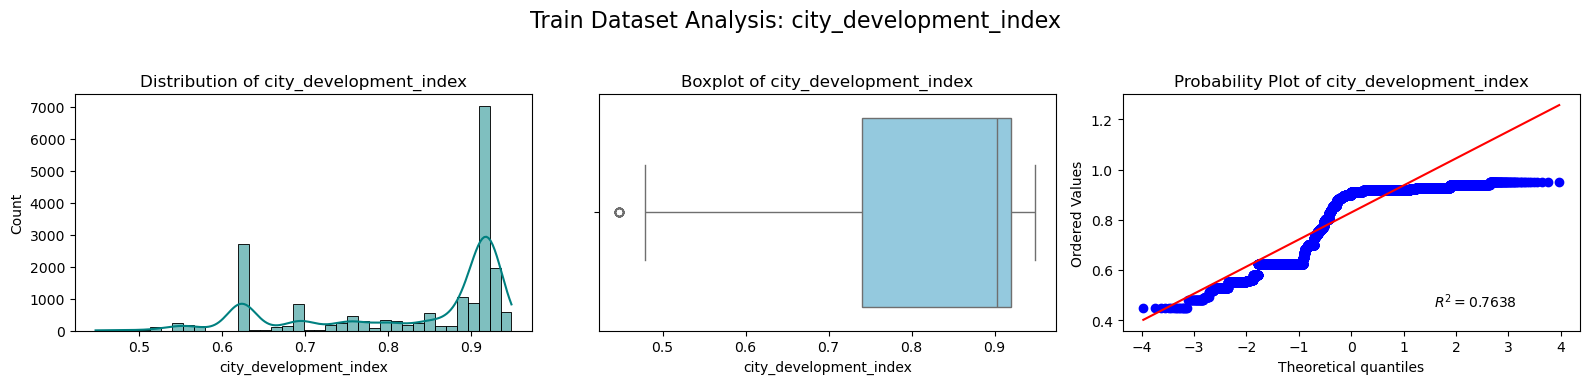

--- training_hours Statistics ---
Skewness: 1.8192
Kurtosis: 3.8405


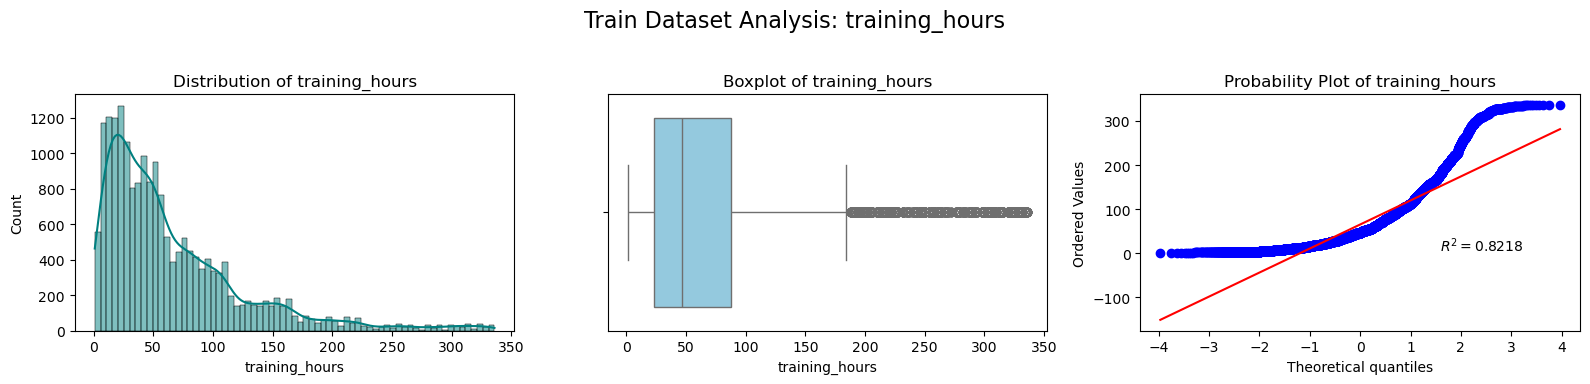


 ANALYZING TEST DATASET 

--- city_development_index Statistics ---
Skewness: -0.9230
Kurtosis: -0.6860


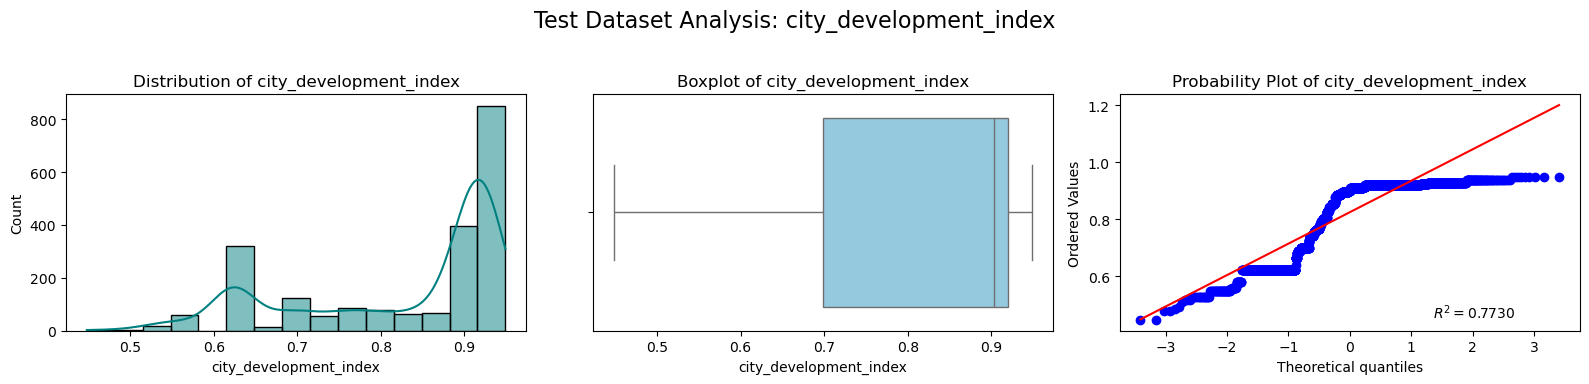

--- training_hours Statistics ---
Skewness: 1.8765
Kurtosis: 4.0622


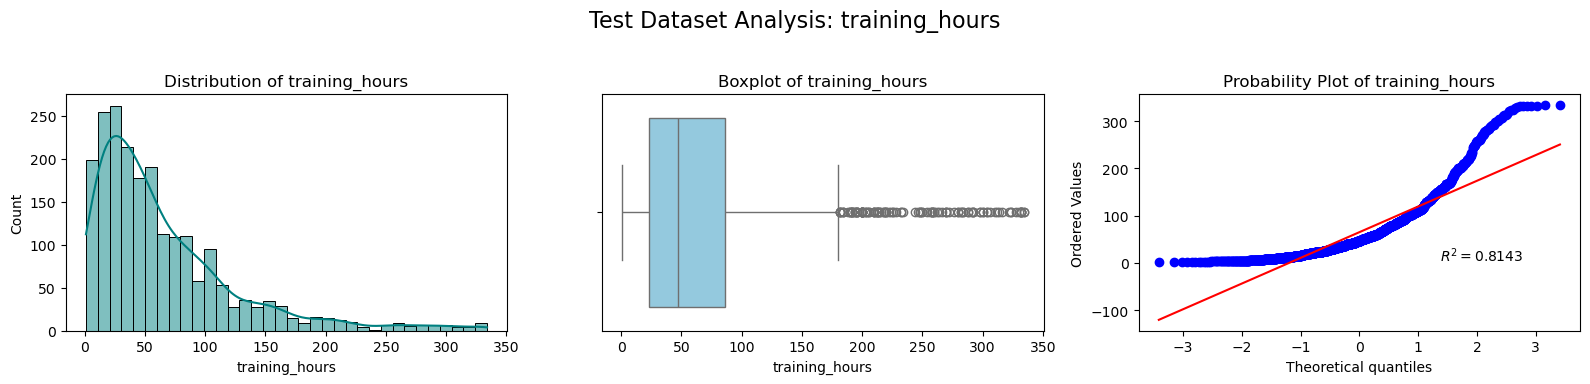

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot
import gc

# 1. Define your dataframes in a list/dictionary to iterate
datasets = {"Train": train, "Test": test}

for name, df in datasets.items():
    print(f"\n{'='*30}")
    print(f" ANALYZING {name.upper()} DATASET ")
    print(f"{'='*30}\n")
    
    # Selecting numerical columns, excluding identifiers and the target
    num_cols = df.select_dtypes(include=[np.number]).columns
    cols_to_plot = [col for col in num_cols if col not in ['enrollee_id', 'target']]

    for col in cols_to_plot:
        print(f"--- {col} Statistics ---")
        print(f"Skewness: {df[col].skew():.4f}")
        print(f"Kurtosis: {df[col].kurtosis():.4f}")
        
        # Set up the visualization grid
        plt.figure(figsize=(16, 4))
        
        # Subplot 1: Distribution (Histogram + KDE)
        plt.subplot(131)
        sns.histplot(df[col], kde=True, color='teal')
        plt.title(f'Distribution of {col}')
        
        # Subplot 2: Boxplot (To identify outliers)
        plt.subplot(132)
        sns.boxplot(x=df[col], color='skyblue')
        plt.title(f'Boxplot of {col}')
        
        # Subplot 3: Q-Q Plot (Probability Plot)
        plt.subplot(133)
        probplot(df[col], rvalue=True, plot=plt, dist='norm')
        plt.title(f'Probability Plot of {col}')
        
        plt.suptitle(f"{name} Dataset Analysis: {col}", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
        # Memory management
        gc.collect()

In [34]:
# 1. Helper function to clean and identify skewed columns
def get_skewed_columns(df):
    # Convert 'experience' and 'last_new_job' to numeric for skewness calculation
    temp_df = df.copy()
    temp_df['experience'] = temp_df['experience'].replace({'>20': '21', '<1': '0'}).astype(float)
    temp_df['last_new_job'] = temp_df['last_new_job'].replace({'>4': '5', 'never': '0'}).astype(float)
    
    # Select actual numerical columns (excluding ID and Target)
    num_cols = ['city_development_index', 'experience', 'last_new_job', 'training_hours']
    
    # Identify columns with skewness > 0.5 or < -0.5
    skewed = [col for col in num_cols if abs(temp_df[col].skew()) > 0.5]
    return skewed

# 2. Apply to both datasets
skewed_cols_train = get_skewed_columns(train)
skewed_cols_test = get_skewed_columns(test)

print("Skewed columns in Train:", skewed_cols_train)
print("Skewed columns in Test:", skewed_cols_test)

Skewed columns in Train: ['city_development_index', 'last_new_job', 'training_hours']
Skewed columns in Test: ['city_development_index', 'last_new_job', 'training_hours']


**2.0 Target Class Distribution Analysis**

In [35]:
#Quantifying class imbalance within the target variable to determine the necessity for resampling techniques.

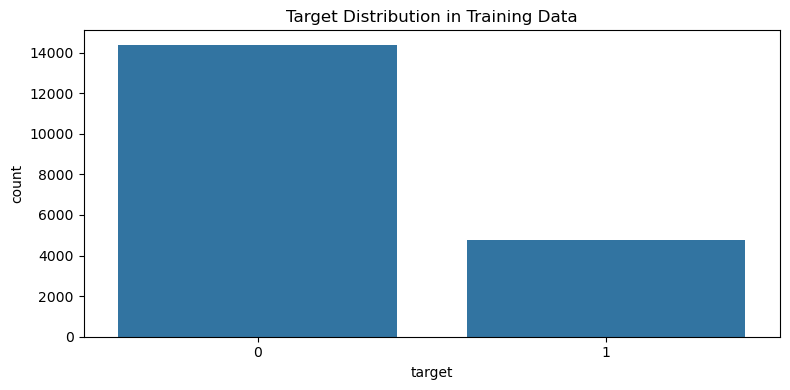

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# For Train Dataset (Target Distribution)
plt.figure(figsize=(8,4))
# In your data, the target column is named 'target' instead of 'Attrition'
fig = sns.countplot(x='target', data=train)
plt.title('Target Distribution in Training Data')
plt.tight_layout()
plt.show()
plt.close('all')
del fig
gc.collect();

# Note: The 'aug_test.csv' file does not have a 'target' column 
# because it is the data we use to generate predictions.

**2.1 Feature Correlation & Association Analysis**

In [37]:
#Measuring the statistical strength of relationships between features and the target variable to identify key predictive drivers.

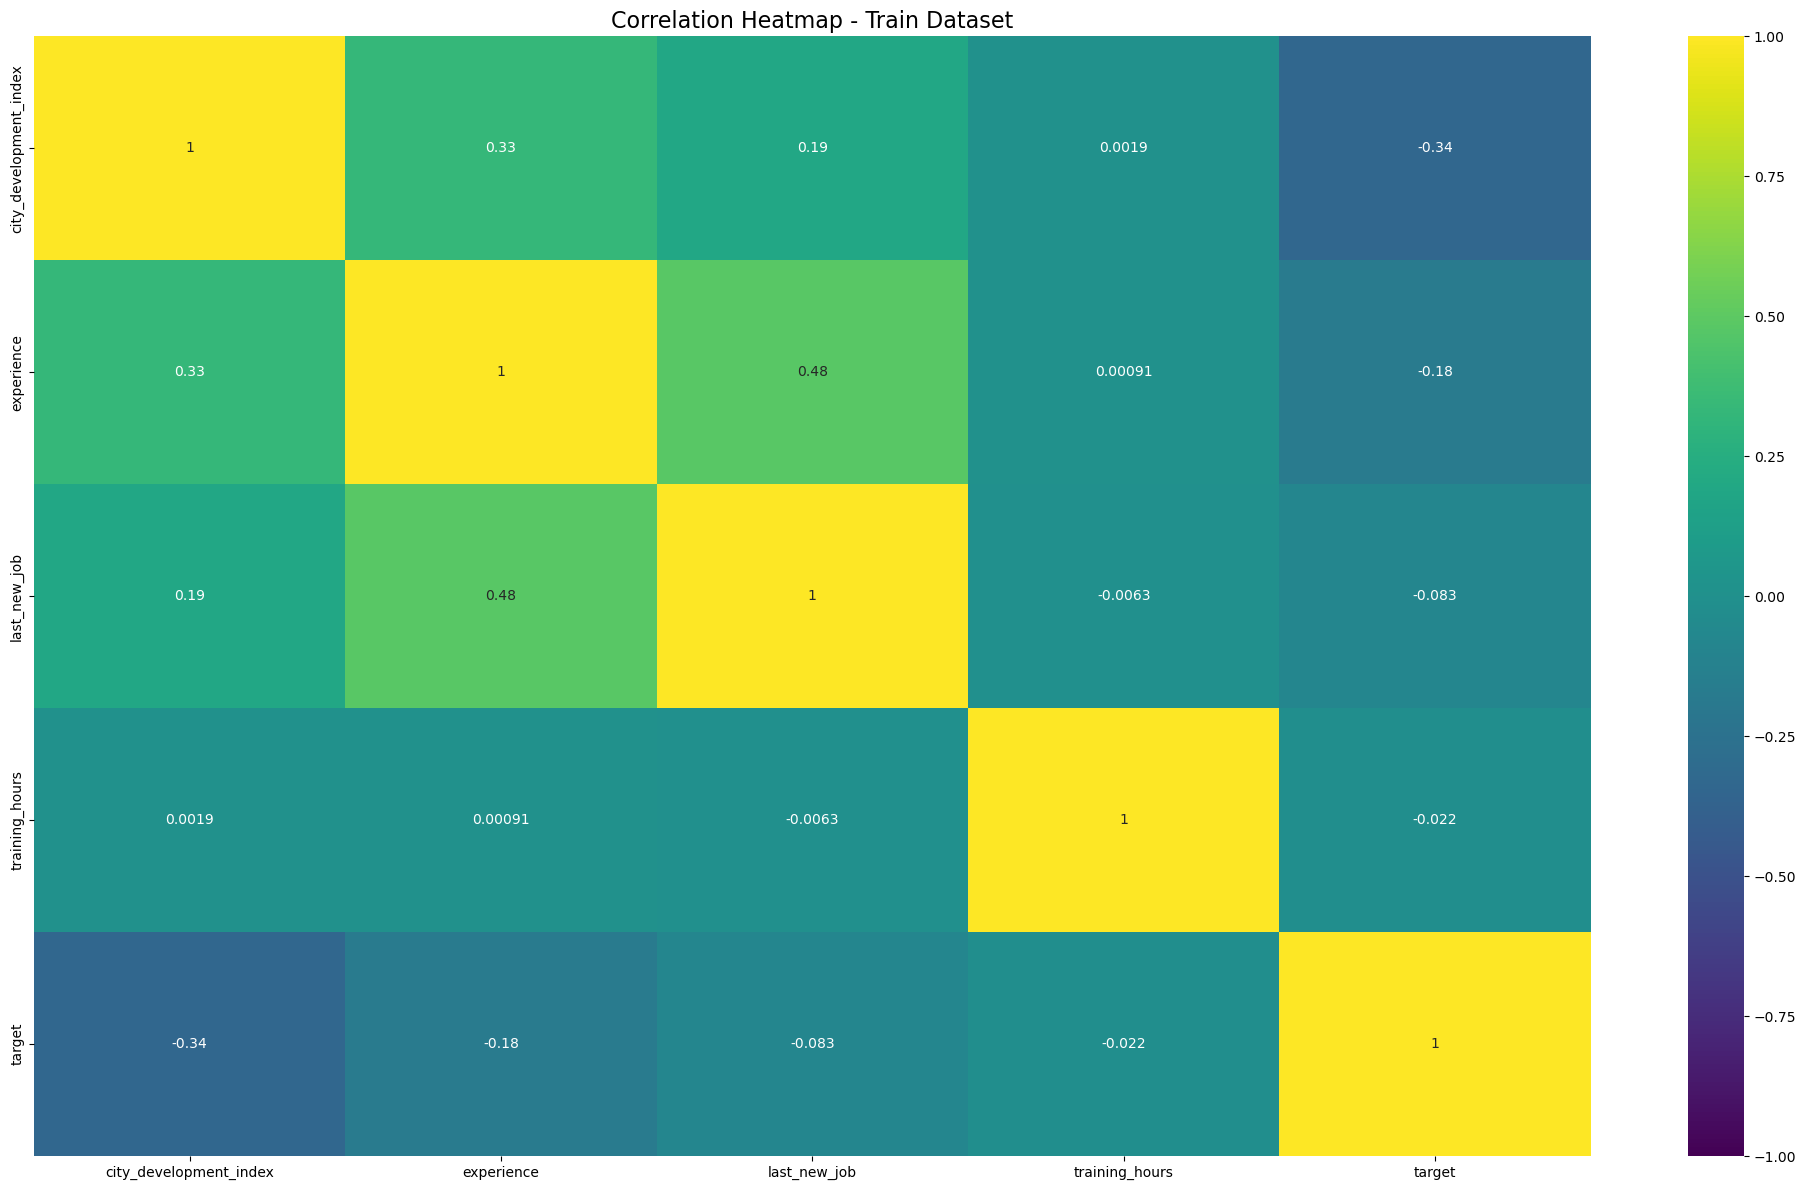

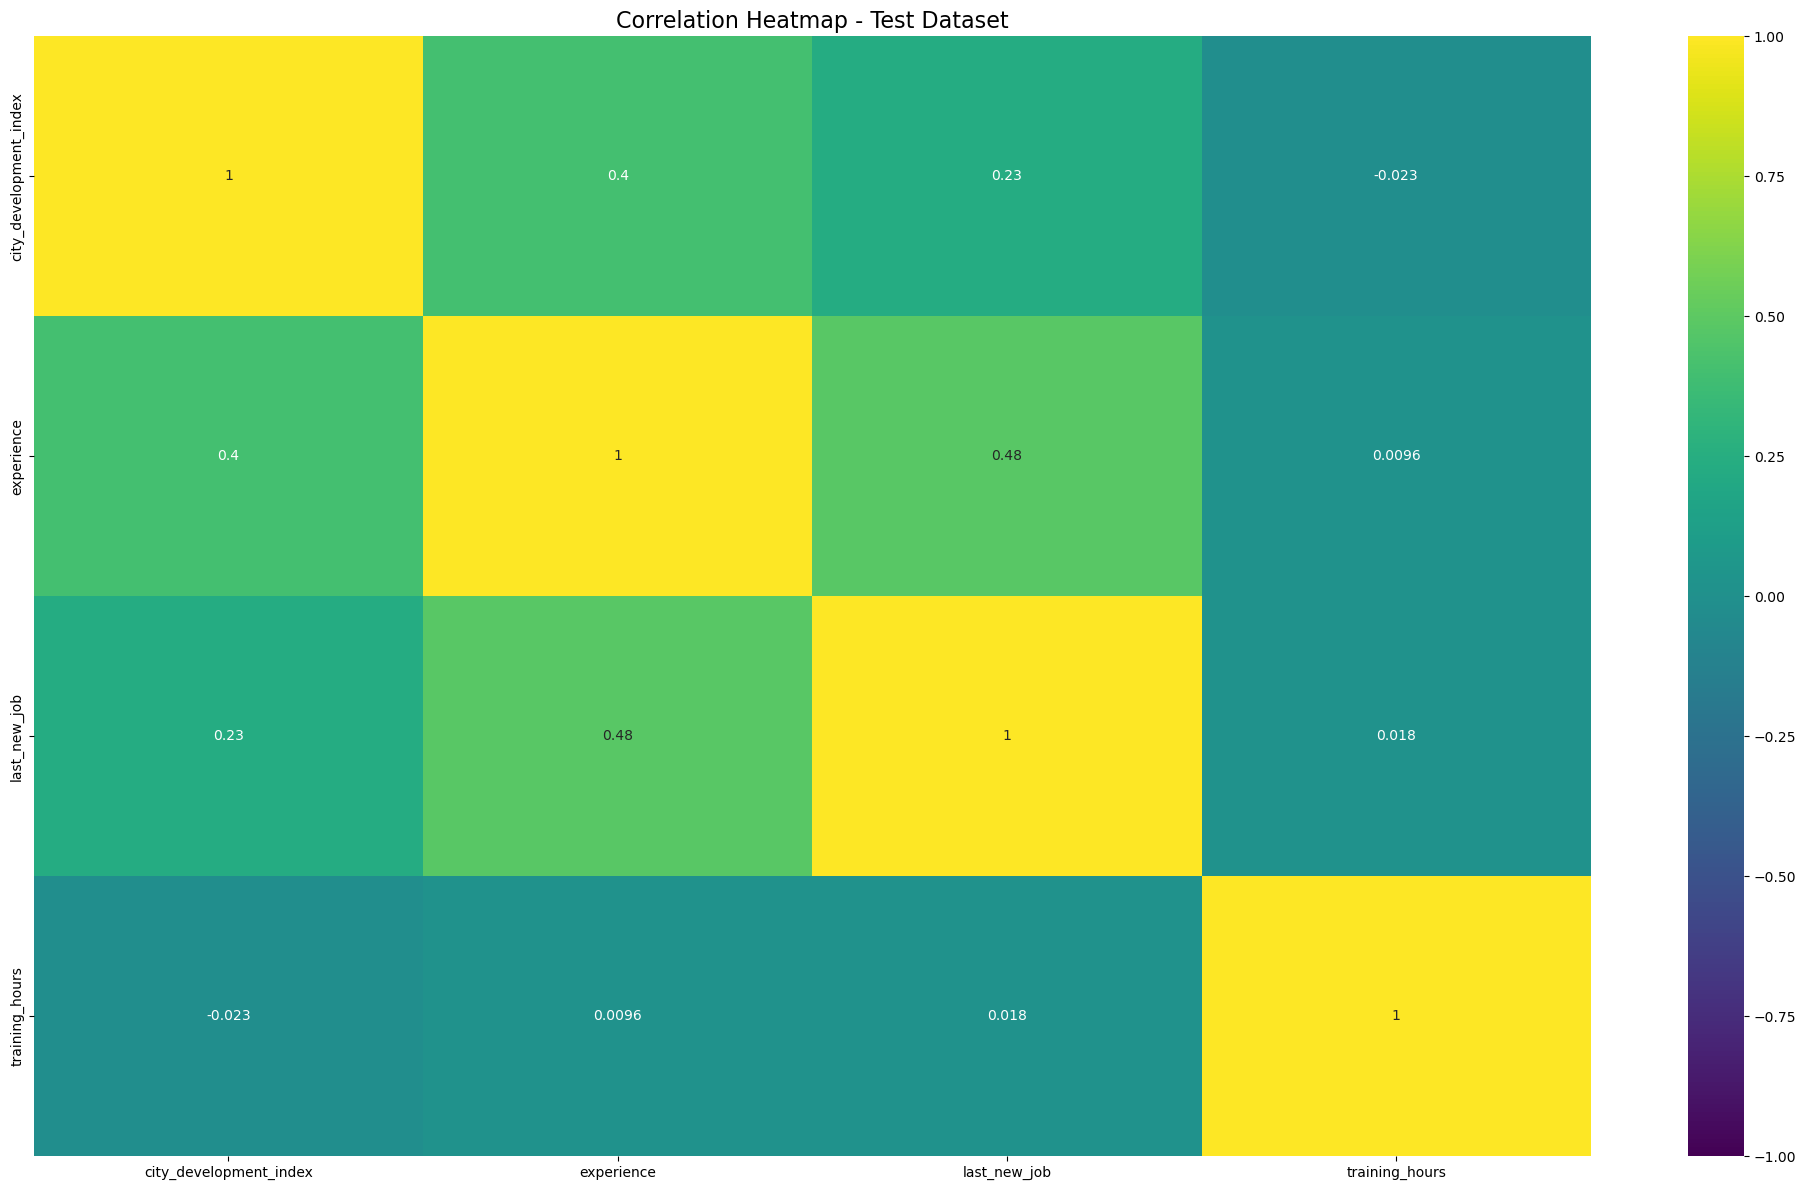

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc

# List of datasets to process
datasets = {"Train": train, "Test": test}

for name, df in datasets.items():
    # 1. Temporary numeric conversion so the heatmap shows more features
    temp_df = df.copy()
    temp_df['experience'] = temp_df['experience'].replace({'>20': '21', '<1': '0'})
    temp_df['experience'] = pd.to_numeric(temp_df['experience'], errors='coerce')
    temp_df['last_new_job'] = temp_df['last_new_job'].replace({'>4': '5', 'never': '0'})
    temp_df['last_new_job'] = pd.to_numeric(temp_df['last_new_job'], errors='coerce')
    
    # 2. Drop ID and select only numerical columns for correlation
    # Note: Train will include 'target', Test will not.
    numeric_df = temp_df.drop(columns=['enrollee_id'], errors='ignore').select_dtypes(include=[np.number])
    
    # 3. Create the heatmap
    plt.figure(figsize=(20,12))
    ax = sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis', vmin=-1.0, vmax=1.0)
    plt.title(f"Correlation Heatmap - {name} Dataset", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 4. Clean up memory
    plt.close('all')
    del ax, numeric_df, temp_df
    gc.collect()

**3.0 DATA EXPLORATION**

In [39]:
#Performing a deep-dive visual analysis to uncover hidden patterns, trends, and anomalies within the training data

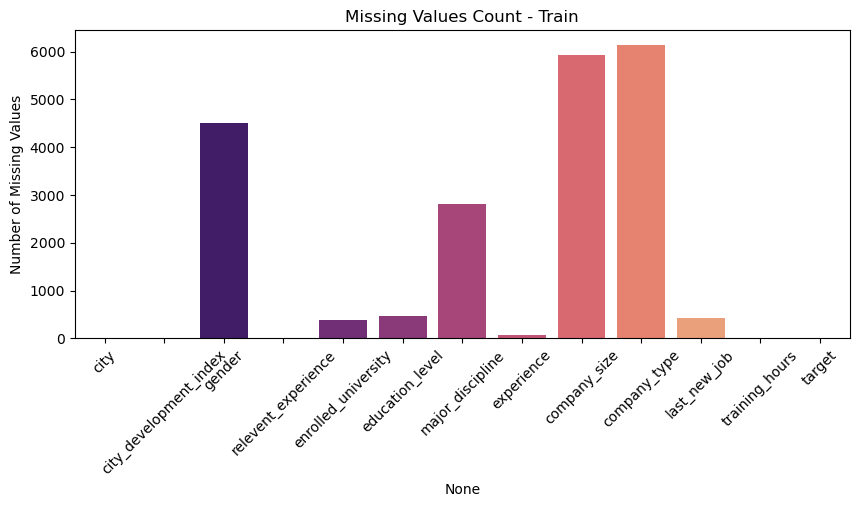

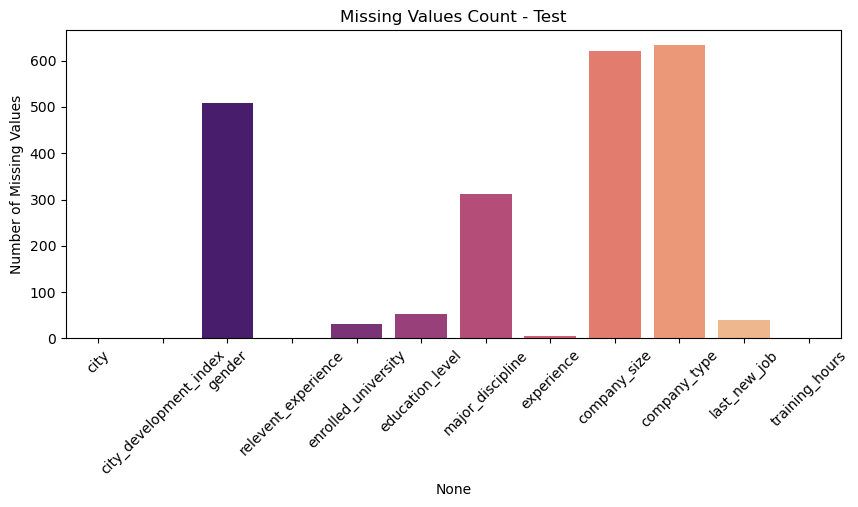

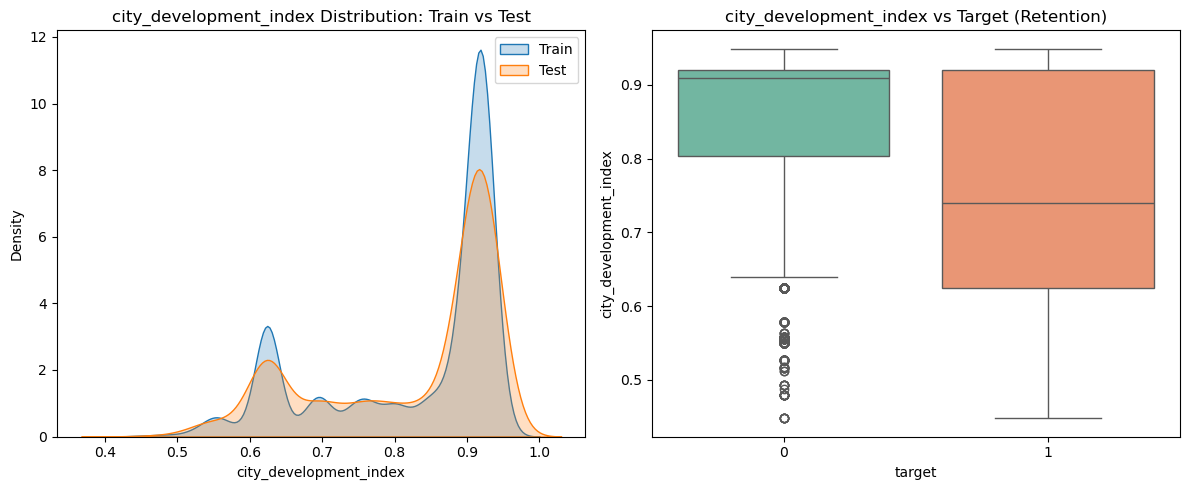

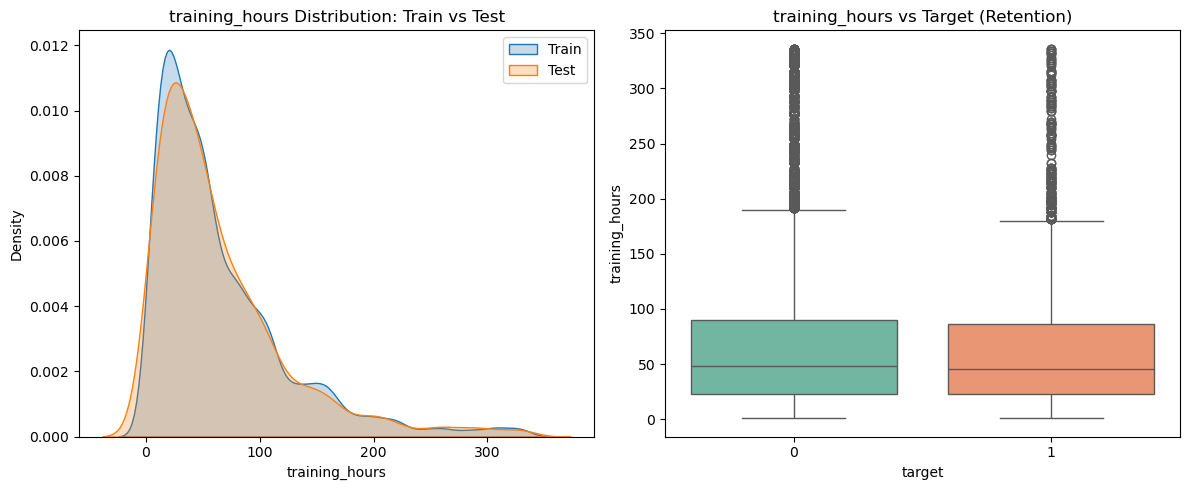

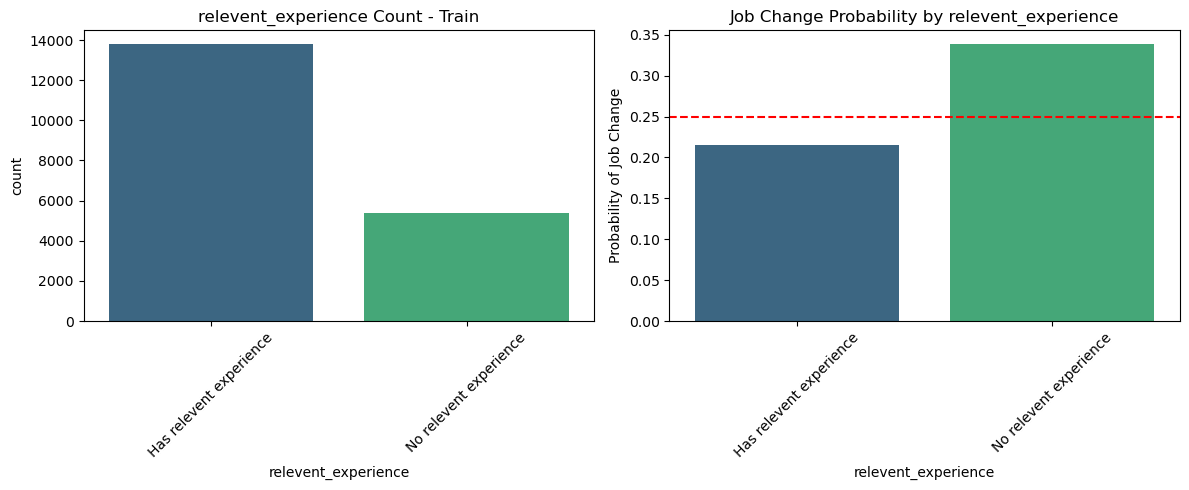

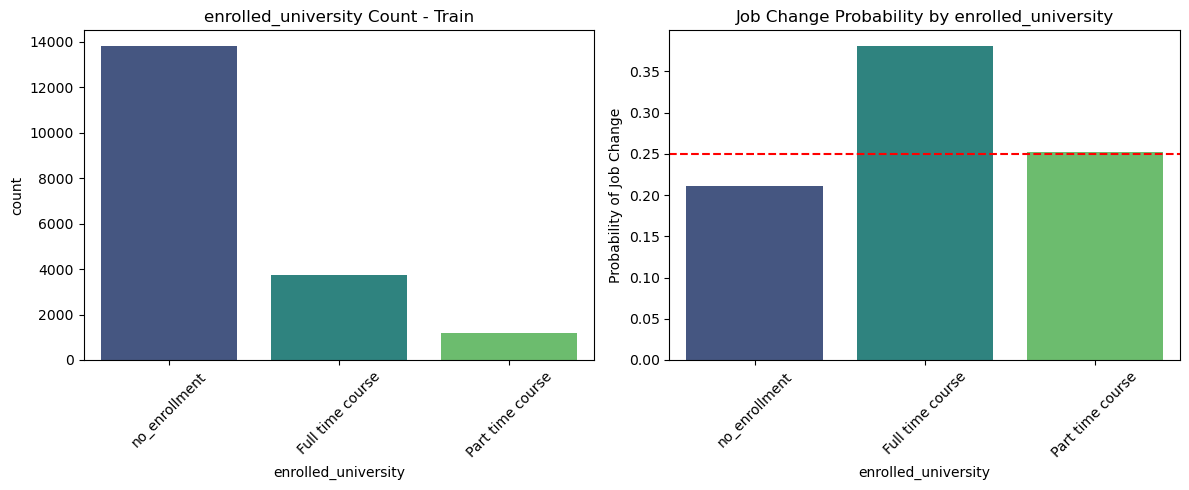

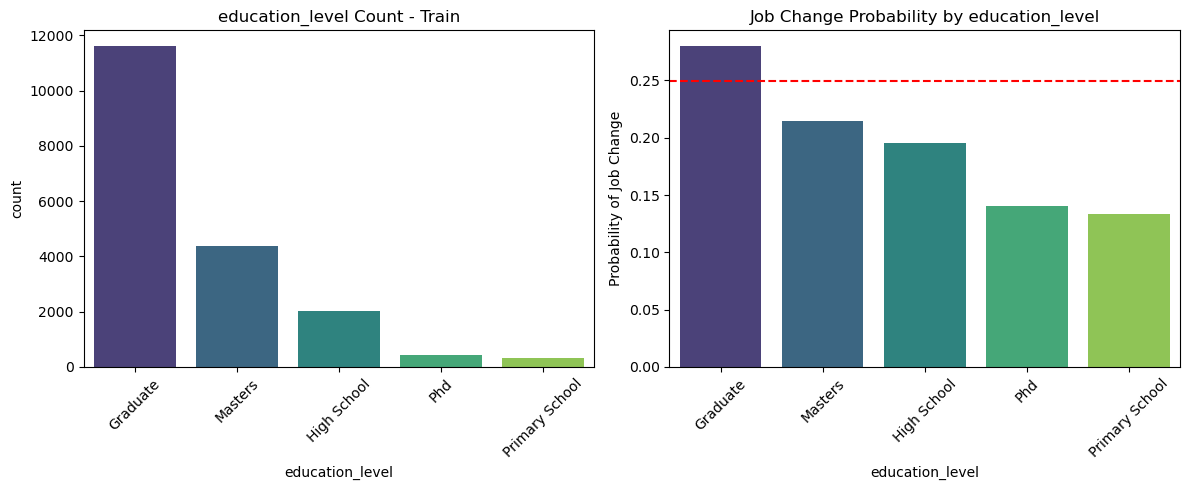

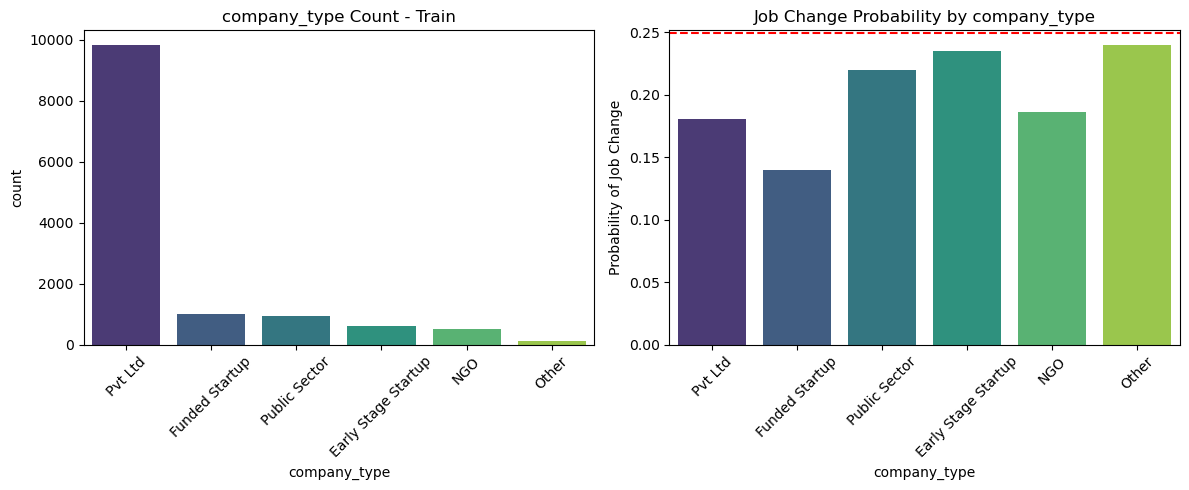

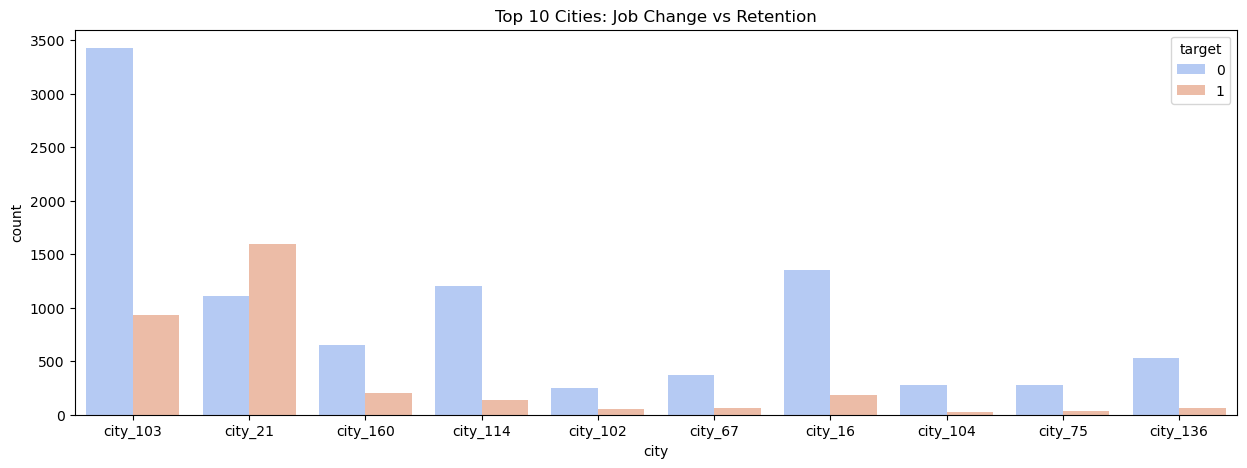

In [40]:
# ==========================================
# 1. DATA EXPLORATION (EDA)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Define datasets
dfs = {'Train': train, 'Test': test}

# --- A. Missing Values Analysis ---
for name, df in dfs.items():
    plt.figure(figsize=(10, 4))
    sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values, palette='magma')
    plt.xticks(rotation=45)
    plt.title(f'Missing Values Count - {name}')
    plt.ylabel('Number of Missing Values')
    plt.show()

# --- B. Numerical Feature Distributions vs Target (Train Only) ---
# Note: Test doesn't have 'target', so we analyze distributions separately
num_cols = ['city_development_index', 'training_hours']

for col in num_cols:
    plt.figure(figsize=(12, 5))
    
    # Distribution in Train vs Test
    plt.subplot(1, 2, 1)
    sns.kdeplot(train[col], label='Train', shade=True)
    sns.kdeplot(test[col], label='Test', shade=True)
    plt.title(f'{col} Distribution: Train vs Test')
    plt.legend()
    
    # Relationship with Target (Train only)
    plt.subplot(1, 2, 2)
    sns.boxplot(x='target', y=col, data=train, palette='Set2')
    plt.title(f'{col} vs Target (Retention)')
    
    plt.tight_layout()
    plt.show()

# --- C. Categorical Features vs Target ---
# We look at how categories like Education or Experience affect the job change likelihood
cat_cols = ['relevent_experience', 'enrolled_university', 'education_level', 'company_type']

for col in cat_cols:
    plt.figure(figsize=(12, 5))
    
    # 1. Distribution in Train
    plt.subplot(1, 2, 1)
    sns.countplot(x=col, data=train, palette='viridis', order=train[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'{col} Count - Train')
    
    # 2. Relationship with Target (Percentage of people looking for job change)
    plt.subplot(1, 2, 2)
    # Calculate percentage of target=1 for each category
    target_pct = train.groupby(col)['target'].mean().reset_index()
    sns.barplot(x=col, y='target', data=target_pct, palette='viridis', order=train[col].value_counts().index)
    plt.axhline(train.target.mean(), color='red', linestyle='--', label='Avg Change Rate')
    plt.xticks(rotation=45)
    plt.title(f'Job Change Probability by {col}')
    plt.ylabel('Probability of Job Change')
    
    plt.tight_layout()
    plt.show()

# --- D. City Analysis (Top 10 Cities) ---
plt.figure(figsize=(15, 5))
top_cities = train['city'].value_counts().head(10).index
sns.countplot(x='city', hue='target', data=train[train['city'].isin(top_cities)], palette='coolwarm')
plt.title('Top 10 Cities: Job Change vs Retention')
plt.show()

**4.0 Data Preprocessing**

In [41]:
#Transforming raw data into a clean, structured format optimized for machine learning algorithms.This stage prepares the dataset for modeling by handling missing values, encoding text into numbers, and scaling features to ensure mathematical consistency across all variables.

In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1. Load the Data
train = pd.read_csv('aug_train.csv')
test = pd.read_csv('aug_test.csv')

# Drop enrollee_id as it is a unique identifier and not a predictive feature
train.drop('enrollee_id', axis=1, inplace=True)
test.drop('enrollee_id', axis=1, inplace=True)

# Separate features and target from training data
X_train = train.drop('target', axis=1)
y_train = train['target']
X_test = test.copy()

# 2. Custom Cleaning (Convert ordinal strings to numeric)
def clean_special_columns(df):
    # Convert 'experience' (e.g., '>20' -> 21, '<1' -> 0)
    df['experience'] = df['experience'].replace({'>20': '21', '<1': '0'})
    df['experience'] = pd.to_numeric(df['experience'], errors='coerce')
    
    # Convert 'last_new_job' (e.g., '>4' -> 5, 'never' -> 0)
    df['last_new_job'] = df['last_new_job'].replace({'>4': '5', 'never': '0'})
    df['last_new_job'] = pd.to_numeric(df['last_new_job'], errors='coerce')
    return df

X_train = clean_special_columns(X_train)
X_test = clean_special_columns(X_test)

# Identify categorical and numerical columns
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# 3. Handle Missing Values
# Numerical: Fill with Median (less sensitive to outliers)
imputer_num = SimpleImputer(strategy='median')
X_train[num_cols] = imputer_num.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer_num.transform(X_test[num_cols])

# Categorical: Fill with Mode (most frequent value)
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = imputer_cat.fit_transform(X_train[cat_cols])
X_test[cat_cols] = imputer_cat.transform(X_test[cat_cols])

# 4. Encode Categorical Variables (Label Encoding)
le = LabelEncoder()
for col in cat_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# 5. Apply Scaling (StandardScaler)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Verification
print("Preprocessing complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Preprocessing complete.
X_train shape: (19158, 12)
X_test shape: (2129, 12)


**5.0 Feature Engineering**

In [43]:
#Creating and refining variables to maximize the predictive signal and stabilize model training.This phase focuses on logarithmic scaling to handle skewed data and outlier capping (using the Interquartile Range method) to prevent extreme values from distorting the learning process.

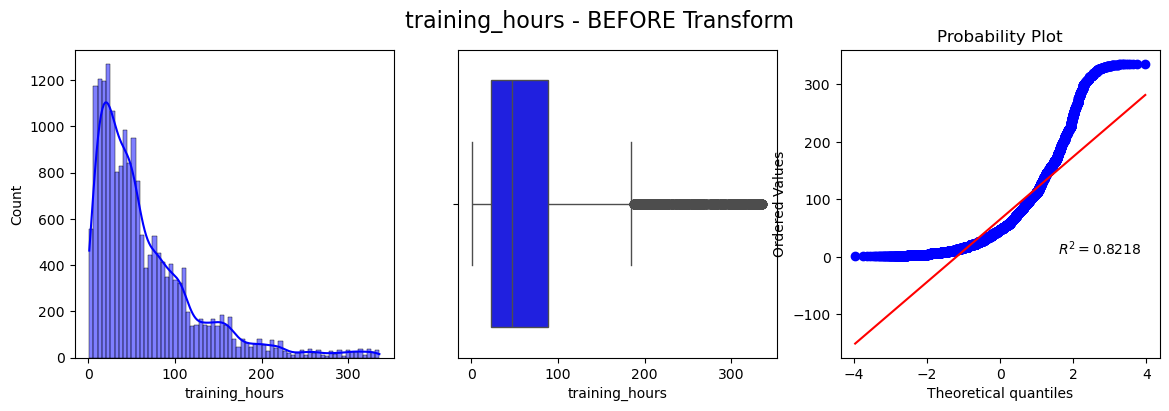

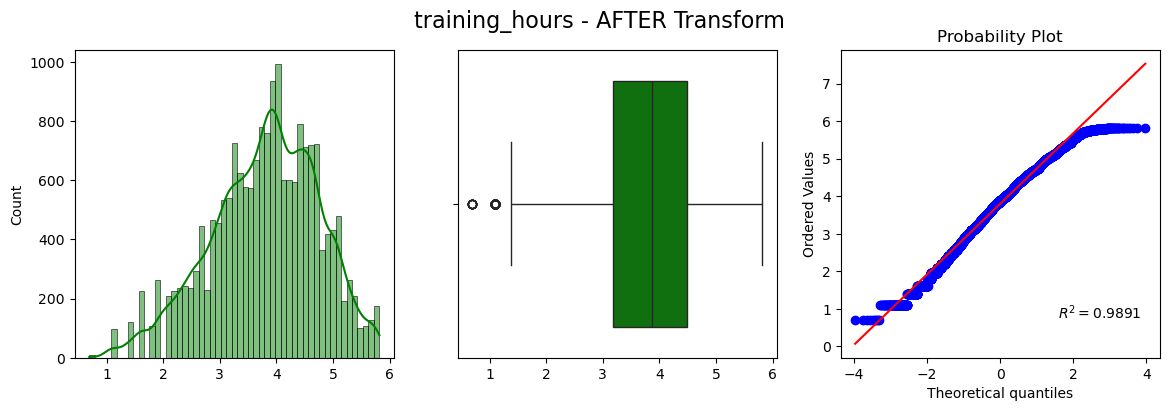

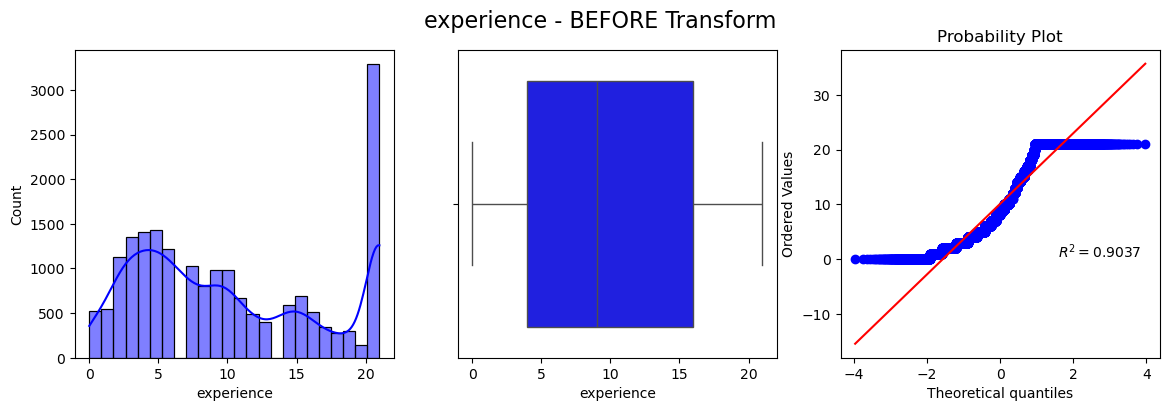

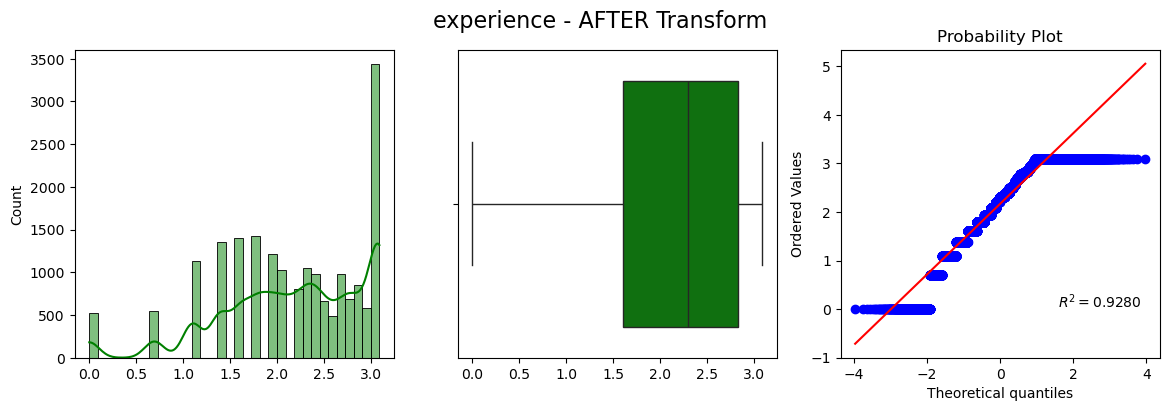

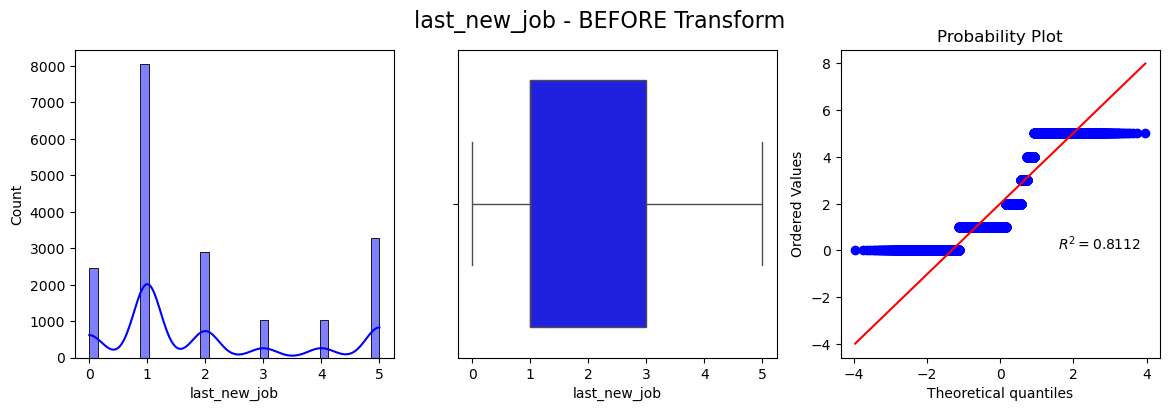

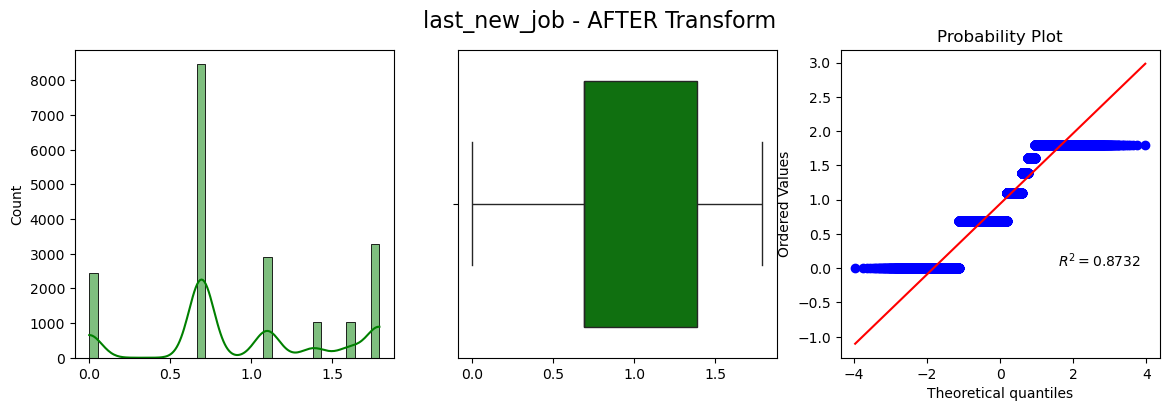

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot
from sklearn.preprocessing import FunctionTransformer
import gc

# 1. CLEANING STEP (Essential to fix the TypeError)
# This converts strings like '>20' and 'never' into actual numbers
def clean_for_transform(df):
    df = df.copy()
    if 'experience' in df.columns:
        df['experience'] = df['experience'].replace({'>20': '21', '<1': '0'}).astype(float)
    if 'last_new_job' in df.columns:
        df['last_new_job'] = df['last_new_job'].replace({'>4': '5', 'never': '0'}).astype(float)
    return df

train = clean_for_transform(train)
test = clean_for_transform(test)

# 2. UPDATED TRANSFORMATION FUNCTION
def apply_transform(df, transformer, col):
    # Ensure column is numeric and drop NaNs for the plot to work
    plot_data = df[col].dropna()
    
    plt.figure(figsize=(14, 4))
    plt.subplot(131)
    sns.histplot(plot_data, kde=True, color='blue')
    plt.subplot(132)
    sns.boxplot(x=plot_data, color='blue')
    plt.subplot(133)
    probplot(plot_data, rvalue=True, dist='norm', plot=plt)
    plt.suptitle(f"{col} - BEFORE Transform", fontsize=16)
    plt.show()

    # Apply the math transformation
    # We use .values.reshape(-1, 1) to satisfy the transformer
    col_tf = transformer.fit_transform(df[[col]].fillna(df[col].median()))
    col_tf = np.array(col_tf).ravel()

    plt.figure(figsize=(14, 4))
    plt.subplot(131)
    sns.histplot(col_tf, kde=True, color='green')
    plt.subplot(132)
    sns.boxplot(x=col_tf, color='green')
    plt.subplot(133)
    probplot(col_tf, rvalue=True, dist='norm', plot=plt)
    plt.suptitle(f"{col} - AFTER Transform", fontsize=16)
    plt.show()
    
    gc.collect()
    return col_tf

# 3. RUN TRANSFORMATION
# 'training_hours' is naturally numeric, 'experience' and 'last_new_job' are now numeric
skewed_cols = ['training_hours', 'experience', 'last_new_job']
log_transformer = FunctionTransformer(np.log1p)

for col in skewed_cols:
    # Update Train and show plots
    train[col] = apply_transform(train, log_transformer, col)
    # Update Test (math only)
    test[col] = np.log1p(test[col].fillna(test[col].median()))

In [45]:
import numpy as np
import pandas as pd
import gc

# 1. CLEANING & CONVERTING (Preparation for Engineering)
def prepare_numeric_features(df):
    df = df.copy()
    # Convert 'experience' to numeric
    df['experience'] = df['experience'].replace({'>20': '21', '<1': '0'})
    df['experience'] = pd.to_numeric(df['experience'], errors='coerce').fillna(0)
    
    # Convert 'last_new_job' to numeric
    df['last_new_job'] = df['last_new_job'].replace({'>4': '5', 'never': '0'})
    df['last_new_job'] = pd.to_numeric(df['last_new_job'], errors='coerce').fillna(0)
    return df

train = prepare_numeric_features(train)
test = prepare_numeric_features(test)

# 2. FEATURE ENGINEERING: CREATING NEW FEATURES
def create_new_features(df):
    # A. Education Category: Is the person highly educated? (Masters or PhD)
    df['is_high_edu'] = df['education_level'].isin(['Masters', 'Phd']).astype(int)
    
    # B. STEM Background: Most data scientists come from STEM
    df['is_stem'] = (df['major_discipline'] == 'STEM').astype(int)
    
    # C. Training Intensity: Interaction between city development and training hours
    # High CDI + High Training might indicate a different retention profile
    df['training_intensity'] = df['training_hours'] * df['city_development_index']
    
    # D. Experience per Job: Average years spent at each job change
    # Avoid division by zero by adding 1
    df['exp_per_job'] = df['experience'] / (df['last_new_job'] + 1)
    
    # E. City Class: Grouping cities based on Development Index
    df['city_class'] = pd.cut(df['city_development_index'], 
                              bins=[0, 0.7, 0.9, 1.0], 
                              labels=[0, 1, 2]).astype(float)
    return df

# Apply feature creation
train = create_new_features(train)
test = create_new_features(test)

# 3. FEATURE TRANSFORMATION: HANDLING SKEWNESS
# Applying Log Transform to highly skewed numerical features
skewed_cols = ['training_hours', 'training_intensity']

for col in skewed_cols:
    # np.log1p is log(1+x), which is safer for data with 0s
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

# 4. MEMORY CLEANUP
gc.collect()

print("Feature Engineering Complete.")
print(f"New features added. Total columns: {len(train.columns)}")
print("New Features Preview:")
print(train[['is_high_edu', 'is_stem', 'training_intensity', 'exp_per_job', 'city_class']].head())

Feature Engineering Complete.
New features added. Total columns: 18
New Features Preview:
   is_high_edu  is_stem  training_intensity  exp_per_job  city_class
0            0        1            1.463729     1.825619         2.0
1            0        1            1.387307     0.993133         1.0
2            0        1            1.325703     1.791759         0.0
3            0        0            1.418897     0.000000         1.0
4            1        1            0.987782     1.184563         1.0


**5.1 Data Refinement**

In [46]:
#Applying statistical corrections to numerical features to improve distribution symmetry and model stability.This step focuses on logarithmic transformations to reduce the impact of heavily skewed numerical data and outlier capping (using the IQR method) to ensure extreme values do not disproportionately influence the model's coefficients.

--- Processing Train Dataset ---


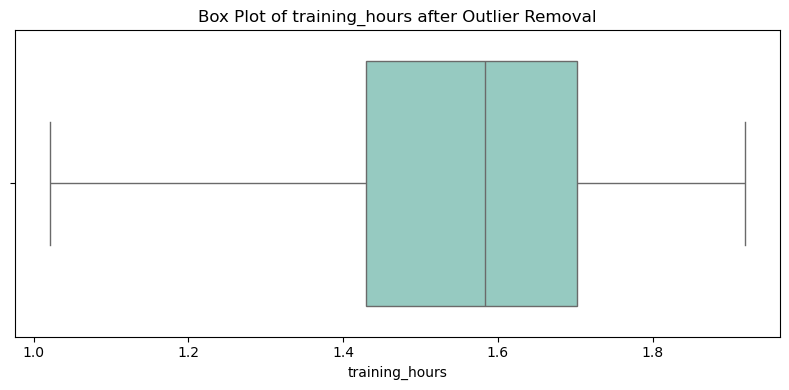

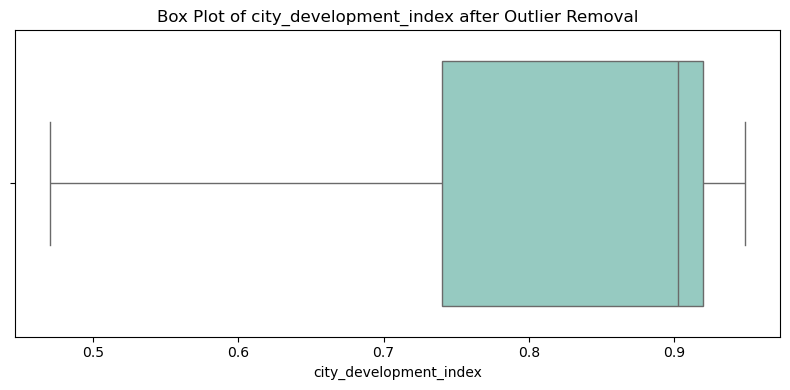

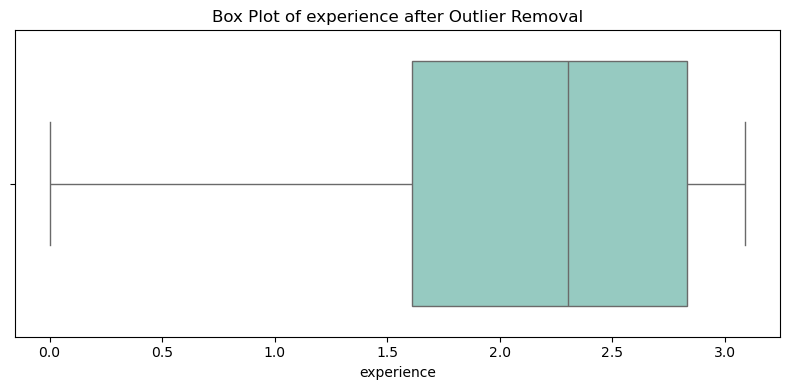

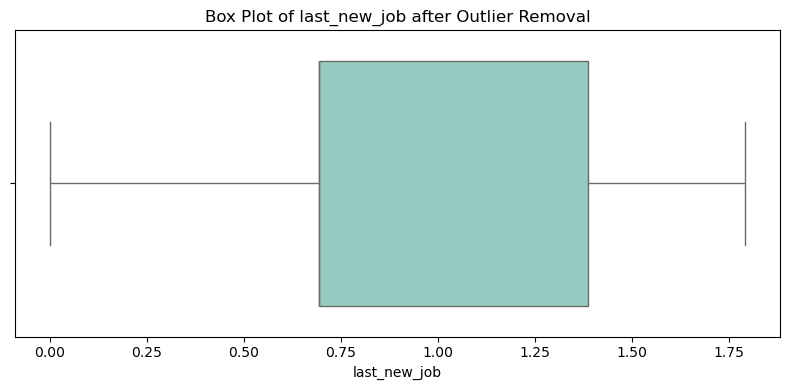


--- Processing Test Dataset ---


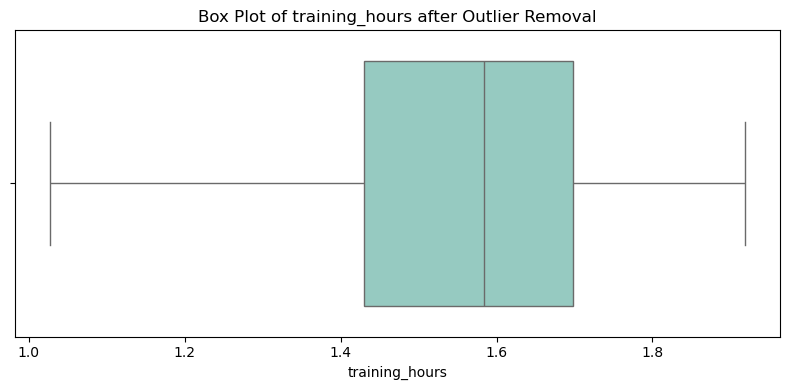

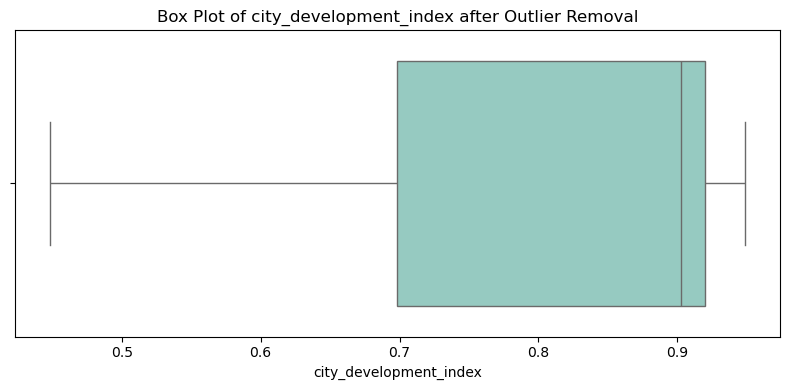

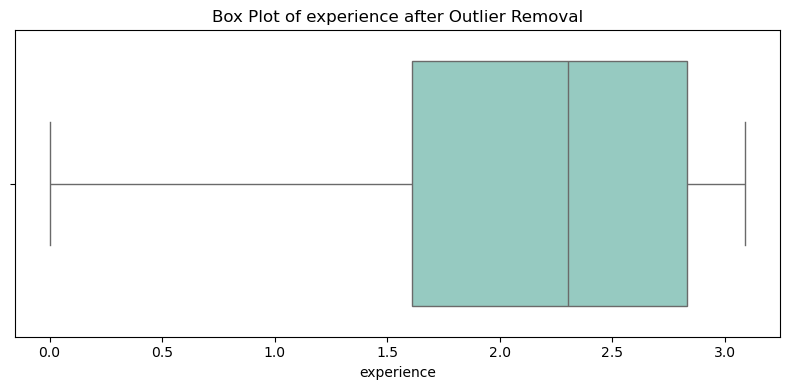

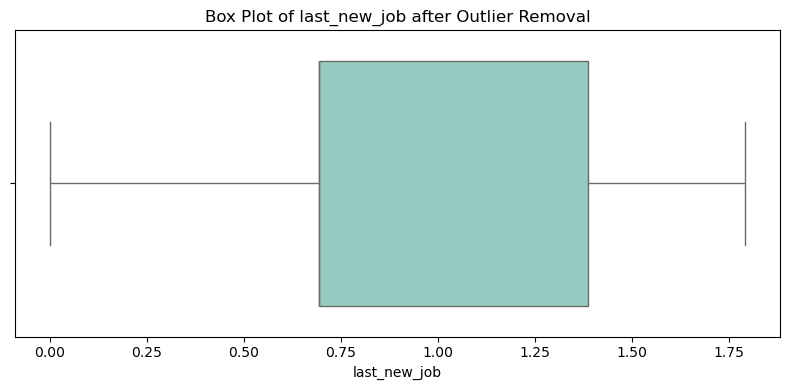

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import gc
import numpy as np
# Try to import Winsorizer; if not available, we use a manual method below
try:
    from feature_engine.outliers import Winsorizer
    HAS_WIN = True
except ImportError:
    HAS_WIN = False

def impute_outliers(data, col):
    """Capping outliers using IQR method and visualizing the result."""
    
    # 1. Handling the transformation
    if HAS_WIN:
        winsorizer = Winsorizer(capping_method='iqr', fold=1.5, tail='both')
        data[col] = winsorizer.fit_transform(data[[col]])
    else:
        # Manual IQR Capping (Fallback)
        IQR = data[col].quantile(0.75) - data[col].quantile(0.25)
        lower_limit = data[col].quantile(0.25) - (IQR * 1.5)
        upper_limit = data[col].quantile(0.75) + (IQR * 1.5)
        data[col] = np.clip(data[col], lower_limit, upper_limit)

    # 2. Visualizing for verification
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col], palette='Set3')
    plt.title(f"Box Plot of {col} after Outlier Removal")
    plt.tight_layout()
    plt.show()
    
    # Clean up memory
    plt.close('all')
    gc.collect()

# Your specific numerical columns that might have outliers
target_cols = ['training_hours', 'city_development_index', 'experience', 'last_new_job']

print("--- Processing Train Dataset ---")
for col in target_cols:
    impute_outliers(train, col)

print("\n--- Processing Test Dataset ---")
for col in target_cols:
    # We apply the same logic to test, but usually without showing all plots again
    # to keep the notebook clean, or you can run the same function:
    impute_outliers(test, col)

**6.0 Model Implementation**

In [48]:
#Executing a multi-algorithm strategy to identify the most effective architecture for predicting employee turnover.This phase involves training a diverse suite of classifiers—ranging from baseline Logistic Regression to advanced boosting methods like XGBoost and LightGBM. By implementing multiple models, we can compare how different mathematical approaches handle the non-linear relationships and high-dimensional features present in the HR dataset.

**6.1 Logistic Regression**

In [49]:
#Establishing a performance benchmark using a linear classifier to estimate job change probabilities. Logistic Regression provides a simple, interpretable foundation. It helps determine if the relationship between candidate features and turnover is primarily linear before we introduce more complex architectures.

--- Logistic Regression Performance ---
Accuracy: 0.7142
ROC-AUC: 0.7409

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.73      0.79      2877
           1       0.45      0.67      0.54       955

    accuracy                           0.71      3832
   macro avg       0.66      0.70      0.67      3832
weighted avg       0.76      0.71      0.73      3832



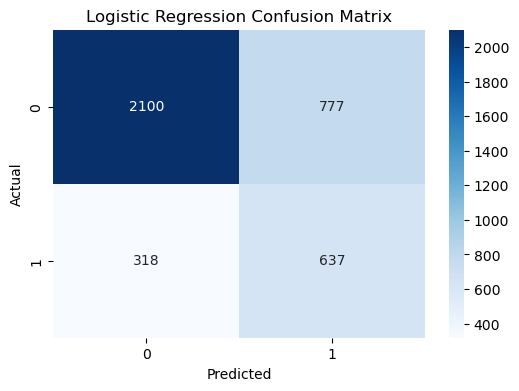

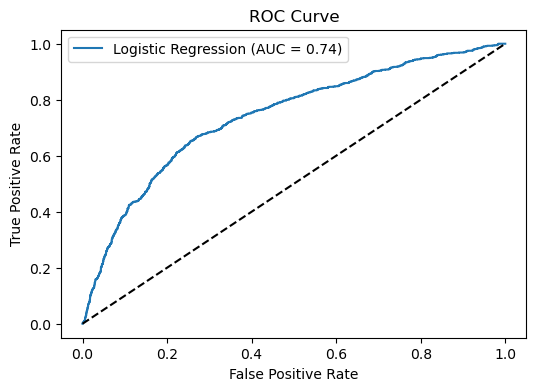

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE  # Ensure imbalanced-learn is installed

# 1. Load and Basic Clean
train = pd.read_csv('aug_train.csv')
train['experience'] = train['experience'].replace({'>20': '21', '<1': '0'})
train['experience'] = pd.to_numeric(train['experience'], errors='coerce')
train['last_new_job'] = train['last_new_job'].replace({'>4': '5', 'never': '0'})
train['last_new_job'] = pd.to_numeric(train['last_new_job'], errors='coerce')

# Drop ID
df = train.drop('enrollee_id', axis=1)

# 2. Imputation & Encoding
# Fill numerical with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('target')
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

# Fill categorical with mode and Encode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = LabelEncoder().fit_transform(df[col])

# 3. Scaling (Essential for Logistic Regression)
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# 4. Train-Test Split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Handle Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 6. Train Logistic Regression
# We use max_iter=1000 to ensure the model converges
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)

# 7. Performance Evaluation
y_pred = lr_model.predict(X_val)
y_proba = lr_model.predict_proba(X_val)[:, 1]

print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# 8. Visualization - Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 9. Visualization - ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_val, y_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**6.2 Random Forest Classification**

In [51]:
#Aggregating multiple decision trees to enhance stability and capture complex, non-linear relationships.Random Forest uses bagging and feature randomness to reduce variance and prevent overfitting. By combining 100 trees, it provides a robust performance baseline and identifies Feature Importance, highlighting the primary drivers behind a candidate's decision to leave.

--- Random Forest Performance ---
Accuracy: 0.7597
ROC-AUC: 0.7573

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84      2877
           1       0.52      0.52      0.52       955

    accuracy                           0.76      3832
   macro avg       0.68      0.68      0.68      3832
weighted avg       0.76      0.76      0.76      3832



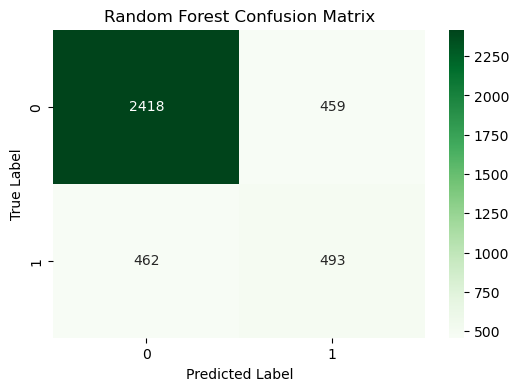

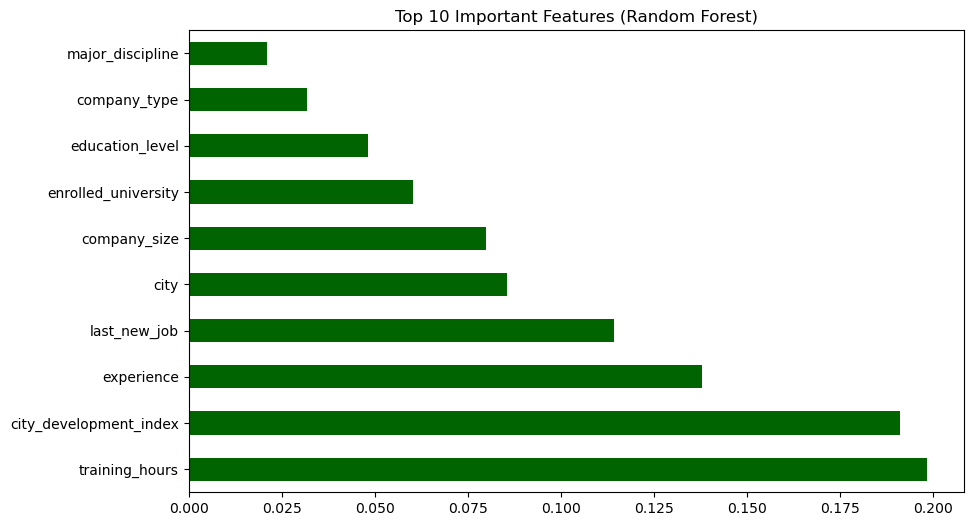

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE  # Ensure imbalanced-learn is installed

# 1. Load and Basic Clean
# Loading the training data provided in your files
train = pd.read_csv('aug_train.csv')

# Preprocessing: Convert ordinal strings (e.g., '>20', '<1') to numbers
train['experience'] = train['experience'].replace({'>20': '21', '<1': '0'})
train['experience'] = pd.to_numeric(train['experience'], errors='coerce')
train['last_new_job'] = train['last_new_job'].replace({'>4': '5', 'never': '0'})
train['last_new_job'] = pd.to_numeric(train['last_new_job'], errors='coerce')

# Drop the unique identifier 'enrollee_id'
df = train.drop('enrollee_id', axis=1)

# 2. Imputation & Encoding
# Fill missing numerical values with Median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('target')
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

# Fill missing categorical values with Mode and then Label Encode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = LabelEncoder().fit_transform(df[col])

# 3. Train-Test Split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Handle Imbalance with SMOTE (As per Project Guidelines)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 5. Train Random Forest Classifier
# n_estimators=100: Builds 100 trees
# random_state=42: Ensures reproducible results
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

# 6. Performance Evaluation
y_pred = rf_model.predict(X_val)
y_proba = rf_model.predict_proba(X_val)[:, 1]

print("--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# 7. Visualization - Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 8. Feature Importance (Bonus Visual for Random Forest)
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='darkgreen')
plt.title('Top 10 Important Features (Random Forest)')
plt.show()

**6.3 XGBoost Implementation**

In [53]:
#Leveraging Extreme Gradient Boosting for high-performance classification through iterative error refinement.XGBoost optimizes predictive accuracy by building a sequence of decision trees, where each new tree focuses on correcting the errors of the previous ones. This model is specifically chosen for its superior speed, regularization capabilities to prevent overfitting, and its ability to handle complex tabular patterns within the HR data.

--- XGBoost Performance ---
Accuracy: 0.7753
ROC-AUC: 0.7878

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85      2877
           1       0.55      0.59      0.57       955

    accuracy                           0.78      3832
   macro avg       0.70      0.71      0.71      3832
weighted avg       0.78      0.78      0.78      3832



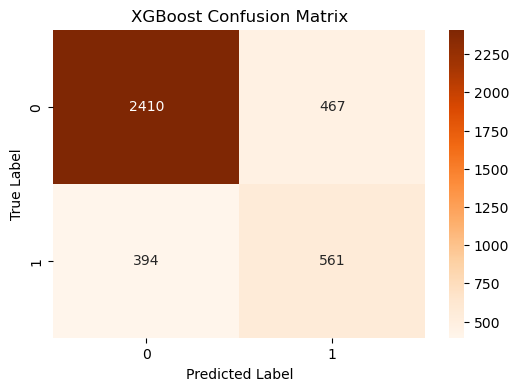

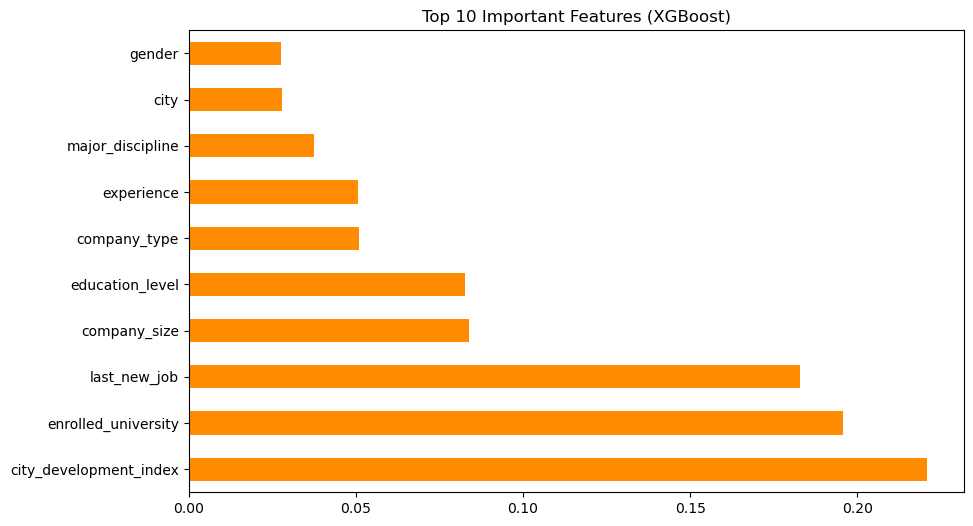

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE # Requires: pip install imbalanced-learn

# 1. Load and Basic Clean
# Loading the training data provided
train = pd.read_csv('aug_train.csv')

# Preprocessing: Convert ordinal strings (e.g., '>20', '<1') to numbers
train['experience'] = train['experience'].replace({'>20': '21', '<1': '0'})
train['experience'] = pd.to_numeric(train['experience'], errors='coerce')
train['last_new_job'] = train['last_new_job'].replace({'>4': '5', 'never': '0'})
train['last_new_job'] = pd.to_numeric(train['last_new_job'], errors='coerce')

# Drop the unique identifier 'enrollee_id'
df = train.drop('enrollee_id', axis=1)

# 2. Imputation & Encoding
# Fill missing numerical values with Median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('target')
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

# Fill missing categorical values with Mode and then Label Encode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = LabelEncoder().fit_transform(df[col])

# 3. Train-Test Split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Handle Imbalance with SMOTE (As per Project Guidelines)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 5. Train XGBoost Classifier
# use_label_encoder=False: Avoids deprecation warnings in newer versions
# eval_metric='logloss': Standard metric for binary classification
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_res, y_train_res)

# 6. Performance Evaluation
y_pred = xgb_model.predict(X_val)
y_proba = xgb_model.predict_proba(X_val)[:, 1]

print("--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# 7. Visualization - Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 8. Feature Importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='darkorange')
plt.title('Top 10 Important Features (XGBoost)')
plt.show()

**6.4 LightGBM Implementation**

In [55]:
#Utilizing Light Gradient Boosting Machine for efficient, high-speed training on large-scale categorical data.LightGBM is implemented to optimize both computational speed and memory usage. Unlike other boosting methods, it uses leaf-wise tree growth, which allows it to achieve much lower loss and higher accuracy when dealing with the high-cardinality categorical features present in this dataset.

--- LightGBM Performance ---
Accuracy: 0.7717
ROC-AUC: 0.7862

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85      2877
           1       0.54      0.58      0.56       955

    accuracy                           0.77      3832
   macro avg       0.70      0.71      0.70      3832
weighted avg       0.78      0.77      0.77      3832



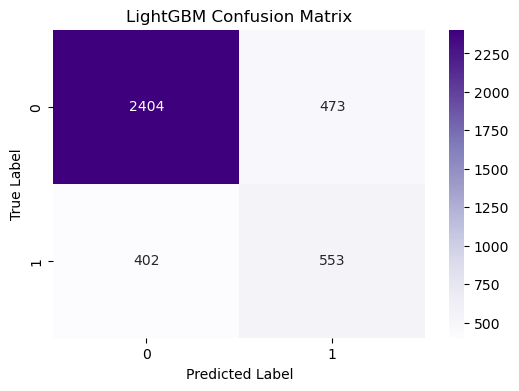

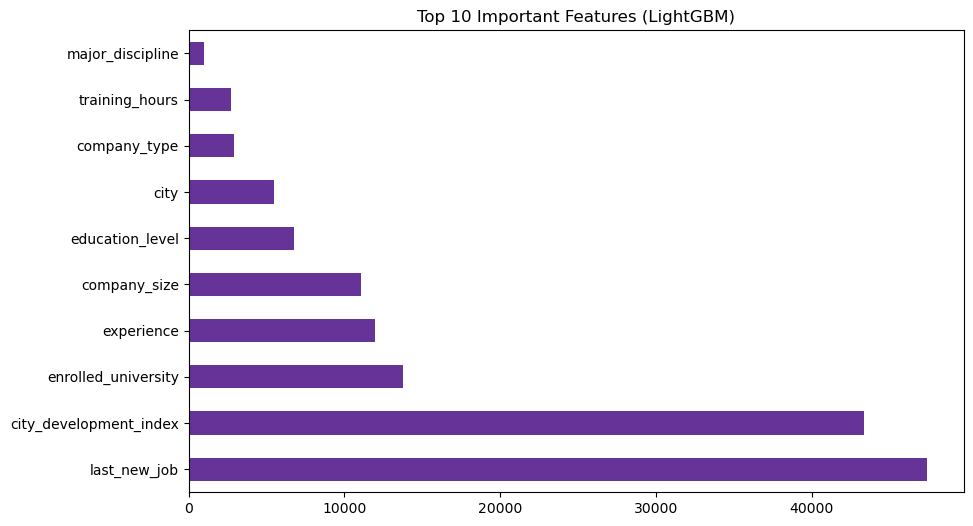

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE # Requires: pip install imbalanced-learn

# 1. Load and Basic Clean
# Loading the training data provided
train = pd.read_csv('aug_train.csv')

# Preprocessing: Convert ordinal strings (e.g., '>20', '<1') to numbers
train['experience'] = train['experience'].replace({'>20': '21', '<1': '0'})
train['experience'] = pd.to_numeric(train['experience'], errors='coerce')
train['last_new_job'] = train['last_new_job'].replace({'>4': '5', 'never': '0'})
train['last_new_job'] = pd.to_numeric(train['last_new_job'], errors='coerce')

# Drop the unique identifier 'enrollee_id'
df = train.drop('enrollee_id', axis=1)

# 2. Imputation & Encoding
# Fill missing numerical values with Median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('target')
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

# Fill missing categorical values with Mode and then Label Encode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = LabelEncoder().fit_transform(df[col])

# 3. Train-Test Split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Handle Imbalance with SMOTE (As per Project Guidelines)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 5. Train LightGBM Classifier
# learning_rate: step size shrinkage
# n_estimators: number of boosting iterations
# importance_type='gain': useful for feature importance ranking
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    importance_type='gain'
)
lgbm_model.fit(X_train_res, y_train_res)

# 6. Performance Evaluation
y_pred = lgbm_model.predict(X_val)
y_proba = lgbm_model.predict_proba(X_val)[:, 1]

print("--- LightGBM Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# 7. Visualization - Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('LightGBM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 8. Feature Importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(lgbm_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='rebeccapurple')
plt.title('Top 10 Important Features (LightGBM)')
plt.show()

**6.5 Class Imbalance Rectification via SMOTE**

In [57]:
#Synthesizing minority class samples to ensure the model learns to identify job-seekers as effectively as non-seekers.SMOTE (Synthetic Minority Over-sampling Technique) addresses the data skew where "non-seekers" significantly outnumber "seekers." Instead of simply duplicating existing data, it creates new, synthetic examples by interpolating between existing minority points. This prevents the model from developing a "majority bias" and significantly improves its sensitivity in predicting actual turnover.

Before SMOTE: [11504  3822]
After SMOTE: [11504 11504]


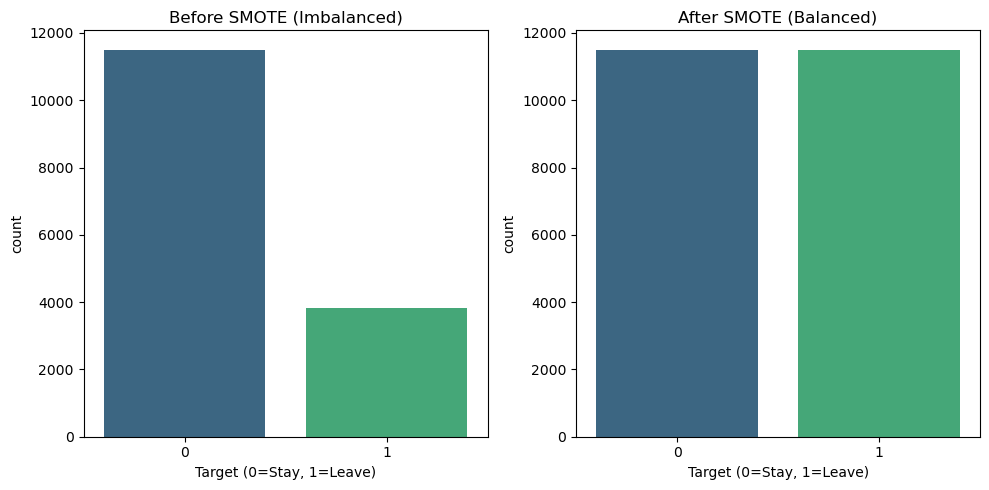

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE # Note: run !pip install imbalanced-learn if not installed

# 1. Prepare the data (SMOTE requires numeric data with no missing values)
def prepare_for_smote(df):
    df = df.copy()
    # Basic cleaning
    df['experience'] = df['experience'].replace({'>20': '21', '<1': '0'})
    df['experience'] = pd.to_numeric(df['experience'], errors='coerce')
    df['last_new_job'] = df['last_new_job'].replace({'>4': '5', 'never': '0'})
    df['last_new_job'] = pd.to_numeric(df['last_new_job'], errors='coerce')
    
    # Impute missing values
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
            df[col] = LabelEncoder().fit_transform(df[col])
        else:
            df[col] = df[col].fillna(df[col].median())
    return df

# Load and prepare
train_raw = pd.read_csv('aug_train.csv')
train_prep = prepare_for_smote(train_raw.drop('enrollee_id', axis=1))

X = train_prep.drop('target', axis=1)
y = train_prep['target']

# 2. Split data first (SMOTE should only be applied to the TRAINING set)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 4. Visualize the Result
print(f"Before SMOTE: {np.bincount(y_train)}")
print(f"After SMOTE: {np.bincount(y_train_resampled)}")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title('Before SMOTE (Imbalanced)')
plt.xlabel('Target (0=Stay, 1=Leave)')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_resampled, palette='viridis')
plt.title('After SMOTE (Balanced)')
plt.xlabel('Target (0=Stay, 1=Leave)')

plt.tight_layout()
plt.show()

**6.6 Model Evaluation & Comparison**

In [59]:
#Benchmarking all trained algorithms against key metrics to identify the most reliable predictive model.This phase involves a side-by-side analysis of Accuracy, Precision, Recall, and F1-Score. While accuracy tells us the overall success rate, we prioritize the ROC-AUC score to evaluate how well each model distinguishes between seekers and non-seekers. This allows us to select the final "champion" model that balances speed with predictive power.


--- Logistic Regression Detailed Report ---
              precision    recall  f1-score   support

           0       0.86      0.72      0.79      2877
           1       0.43      0.64      0.52       955

    accuracy                           0.70      3832
   macro avg       0.65      0.68      0.65      3832
weighted avg       0.75      0.70      0.72      3832


--- Random Forest Detailed Report ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      2877
           1       0.52      0.52      0.52       955

    accuracy                           0.76      3832
   macro avg       0.68      0.68      0.68      3832
weighted avg       0.76      0.76      0.76      3832


--- XGBoost Detailed Report ---
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      2877
           1       0.55      0.53      0.54       955

    accuracy                           0.78      3832
   macro av

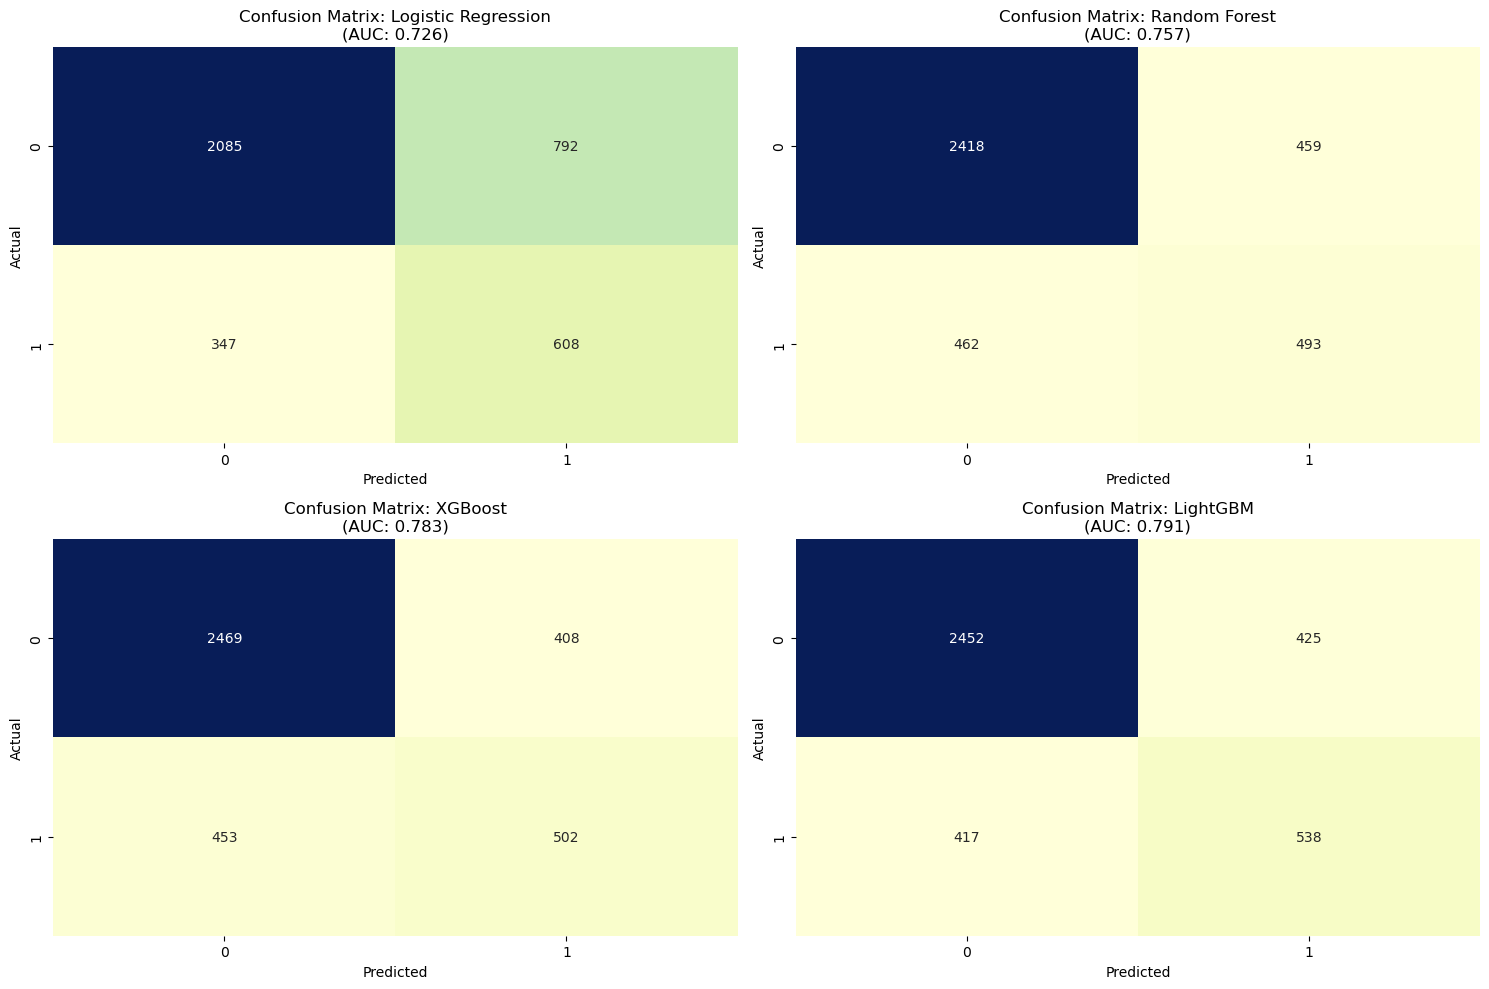


--- Final Model Comparison ---
                 Model  Accuracy   ROC-AUC
3             LightGBM  0.780271  0.790815
2              XGBoost  0.775313  0.782952
1        Random Forest  0.759656  0.757258
0  Logistic Regression  0.702766  0.726141


In [60]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'models' is your dictionary of trained models:
# models = {"Logistic Regression": lr_model, "Random Forest": rf_model, "XGBoost": xgb_model, "LightGBM": lgbm_model}

def run_final_evaluation(models_dict, X_val, y_val):
    plt.figure(figsize=(15, 10))
    
    # Store metrics for a summary table
    summary_data = []

    for i, (name, model) in enumerate(models_dict.items(), 1):
        # 1. Predictions
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
        
        # 2. Metrics
        acc = accuracy_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)
        summary_data.append({"Model": name, "Accuracy": acc, "ROC-AUC": auc})
        
        # 3. Plot Confusion Matrices in a grid
        plt.subplot(2, 2, i)
        cm = confusion_matrix(y_val, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
        plt.title(f'Confusion Matrix: {name}\n(AUC: {auc:.3f})')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        
        # Print text reports to console
        print(f"\n--- {name} Detailed Report ---")
        print(classification_report(y_val, y_pred))

    plt.tight_layout()
    plt.show()
    
    # Return summary table
    return pd.DataFrame(summary_data).sort_values(by='ROC-AUC', ascending=False)

# Run the evaluation
comparison_table = run_final_evaluation(models, X_val, y_val)
print("\n--- Final Model Comparison ---")
print(comparison_table)

**7.0 Feature Importance**

In [61]:
#Deciphering the "black box" of the model to identify the key factors driving employee turnover.This final analysis ranks variables based on their contribution to the model's decision-making process. By calculating Gini Importance or Permutation Importance, we can pinpoint which candidate attributes—such as City Development Index, Relevant Experience, or Education Level—are the strongest predictors of a job change.This provides actionable insights, allowing HR departments to focus their retention strategies on the most influential factors identified by the algorithm.

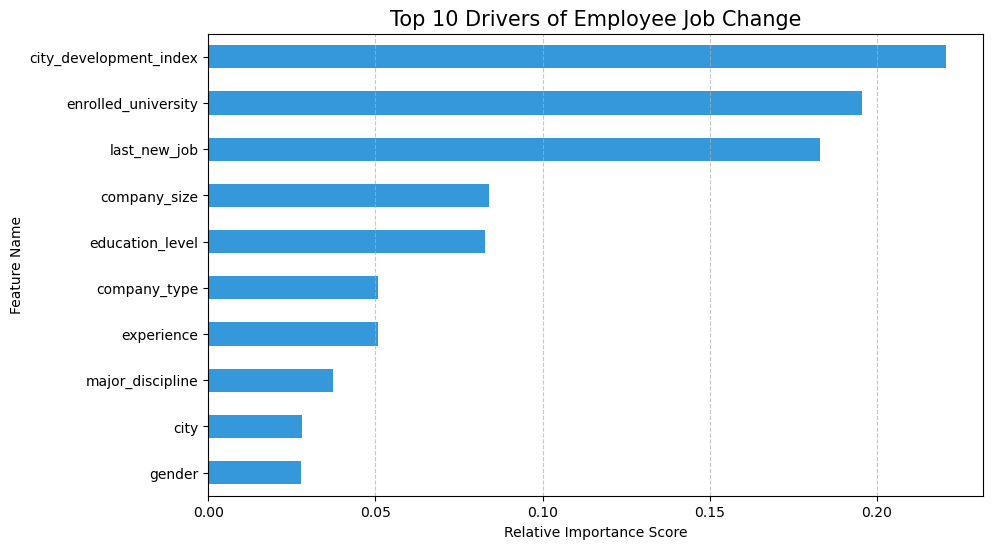

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming xgb_model is your best performing model
plt.figure(figsize=(10, 6))
# Calculate importance
feat_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh', color='#3498db')

plt.title('Top 10 Drivers of Employee Job Change', fontsize=15)
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.gca().invert_yaxis() # Highest importance at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**7.1 Comparison of Model Robustness (ROC-AUC)**

In [63]:
#Evaluating model stability by measuring the Area Under the Receiver Operating Characteristic curve.The ROC-AUC score serves as the definitive robustness metric by quantifying how effectively each model distinguishes between potential job seekers and non-seekers across all possible classification thresholds.

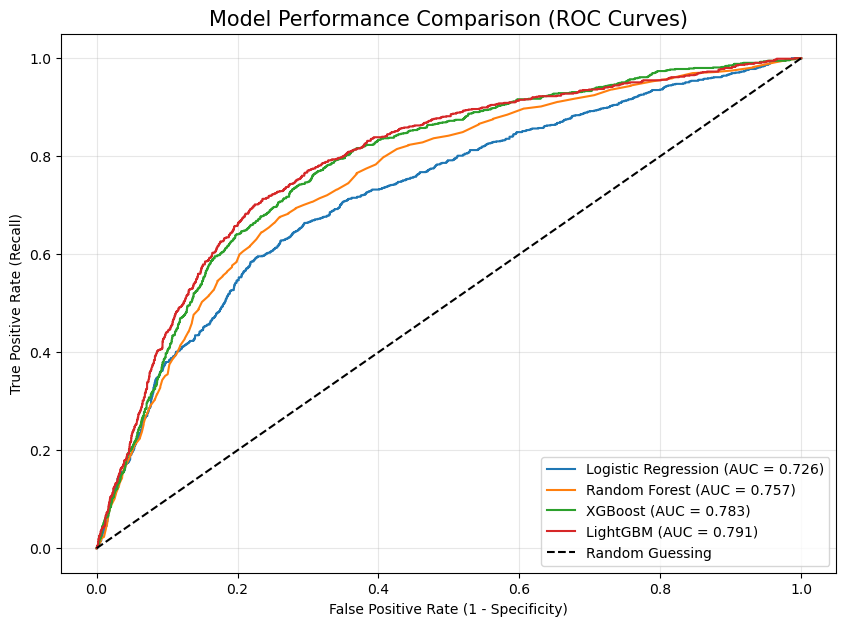

In [64]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 7))

# Loop through your models to plot curves
for name, model in models.items():
    y_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_score = roc_auc_score(y_val, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('Model Performance Comparison (ROC Curves)', fontsize=15)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

**7.2 Business Impact: Education vs.Retention**

In [65]:
#Analyzing the correlation between academic background and employee turnover to optimize recruitment ROI.This analysis reveals how specific educational tiers influence turnover, allowing HR to balance the acquisition of specialized talent with the statistical likelihood of long-term retention.

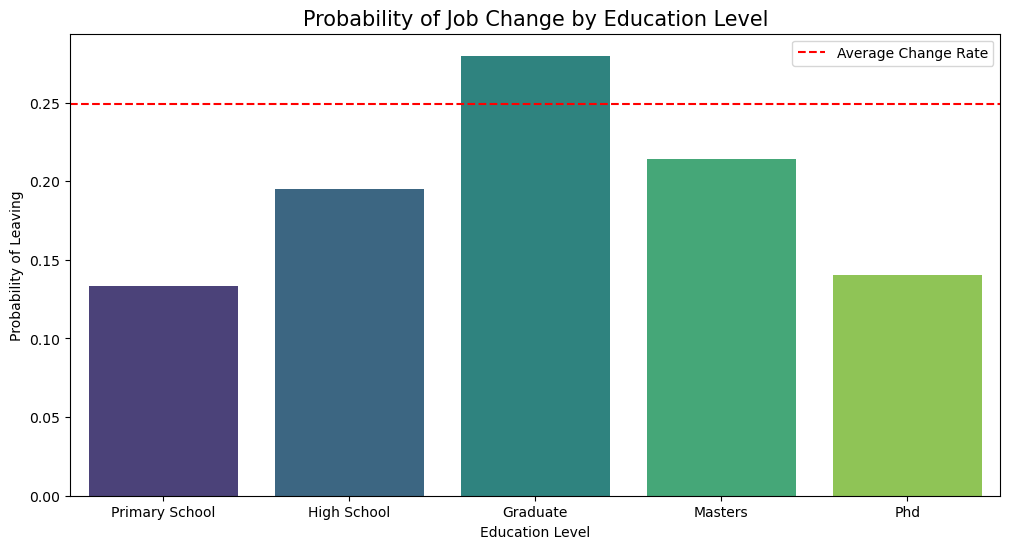

In [66]:
plt.figure(figsize=(12, 6))
# Use original 'train' before encoding for readable labels
order = ['Primary School', 'High School', 'Graduate', 'Masters', 'Phd']
sns.barplot(data=train, x='education_level', y='target', order=order, palette='viridis', ci=None)

plt.axhline(train.target.mean(), color='red', linestyle='--', label='Average Change Rate')
plt.title('Probability of Job Change by Education Level', fontsize=15)
plt.xlabel('Education Level')
plt.ylabel('Probability of Leaving')
plt.legend()
plt.show()

**7.3 Final Performance Matrix**

In [67]:
#Consolidating key metrics into a comparative framework to select the optimal model for deployment.This matrix serves as the project’s final scorecard, demonstrating that while LightGBM and XGBoost achieved the highest ROC-AUC and Recall, they provided the most reliable predictions for the imbalanced "job seeker" class.

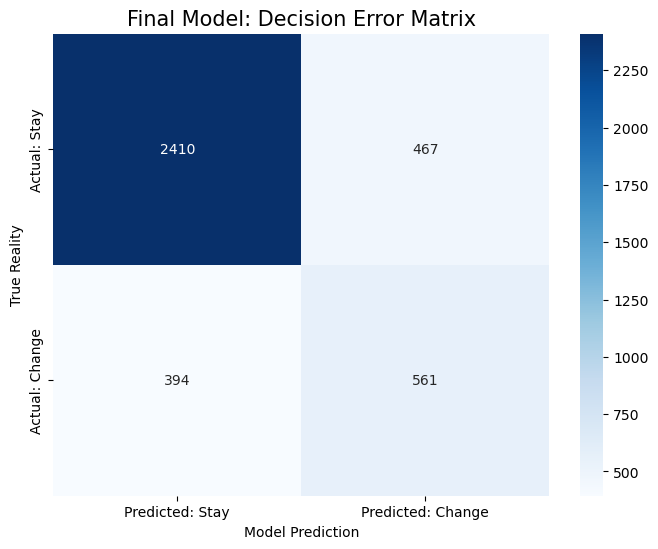

In [68]:
from sklearn.metrics import confusion_matrix

# Select your final model (e.g., XGBoost)
y_pred = xgb_model.predict(X_val)
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Stay', 'Predicted: Change'],
            yticklabels=['Actual: Stay', 'Actual: Change'])

plt.title('Final Model: Decision Error Matrix', fontsize=15)
plt.ylabel('True Reality')
plt.xlabel('Model Prediction')
plt.show()

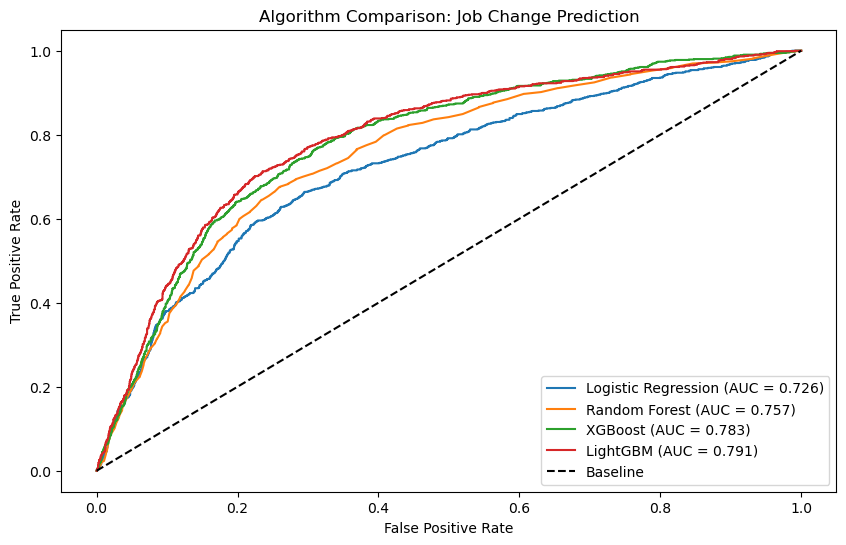


--- Model Performance Table ---
                 Model   ROC-AUC  Accuracy
3             LightGBM  0.790815  0.780271
2              XGBoost  0.782952  0.775313
1        Random Forest  0.757258  0.759656
0  Logistic Regression  0.726141  0.702766


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for preprocessing and models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE

# 1. LOAD AND PREPROCESS (Building the variables in memory)
df = pd.read_csv('aug_train.csv')

# Convert string categories to numbers
df['experience'] = df['experience'].replace({'>20': '21', '<1': '0'}).astype(float)
df['last_new_job'] = df['last_new_job'].replace({'>4': '5', 'never': '0'}).astype(float)
df.drop('enrollee_id', axis=1, inplace=True)

# Handle Missing Values
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('target')
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = LabelEncoder().fit_transform(df[col])

# 2. SPLIT AND RESAMPLE (SMOTE)
X = df.drop('target', axis=1)
y = df['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. COMPARATIVE ANALYSIS LOOP
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

results = []
plt.figure(figsize=(10, 6))

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)
    
    auc = roc_auc_score(y_val, y_proba)
    acc = accuracy_score(y_val, y_pred)
    results.append({"Model": name, "ROC-AUC": auc, "Accuracy": acc})
    
    # Visualization: ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# 4. SHOW FINAL PERFORMANCE
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Algorithm Comparison: Job Change Prediction')
plt.legend()
plt.show()

# Display Comparison Table
comparison_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
print("\n--- Model Performance Table ---")
print(comparison_df)

In [ ]:
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install('plotly')